In [1]:
from calendar import monthrange
import sqlite3
import pandas as pd
import datetime
import numpy as np
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import grib2io
import pygrib
import numpy as np
import math
import seaborn as sns
import statistics as stat

pd.set_option('display.max_rows', 1500)
pd.set_option('display.max_columns', None)

ModuleNotFoundError: No module named 'grib2io'

## Functions

In [1]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    """
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of earth in kilometers. Use 3956 for miles
    return c * r

def K2F(K):
       return (K - 273.15) * 9/5 + 32

## Model Elevation

In [3]:
grbs = pygrib.open('global_orography.t126.grb')
msg = grbs.select(name='Geometrical height')[0]

In [4]:
# Extract Out Colorado
# lats = msg.latitudes
# lons = msg.longitudes
lats,lons = msg.latlons()
dat = msg.values
#print(len(dat))
elevs = {} 
index=0
for j,d in enumerate(dat):
  #  lat = lats[j]
   # print(j,lat)
    for i,val in enumerate(d):
        lat = lats[j][i]
        lon = lons[j][i]
    #    print(lat,lon)
        index+=1
        if lat > 37.0 and lat < 41.1 and lon > 250.9 and lon < 258:
            print(i,j,lats[j,i],lons[j,i],dat[j,i]*3.28084)
            if j not in elevs:
                elevs[j]={}
            if i not in elevs[j]:
                elevs[j][i]={}
                
            elevs[j][i]["lat"]= lat
            elevs[j][i]["lon"]= lon
            elevs[j][i]["index"]= index
            elevs[j][i]["elv"]= dat[j,i]*3.28084
            
            

269 52 40.157313795301285 251.2496501305471 7541.666908000001
270 52 40.157313795301285 252.18714882506407 8777.559336
271 52 40.157313795301285 253.12464751958103 8765.092144000002
272 52 40.157313795301285 254.062146214098 7210.302068000001
273 52 40.157313795301285 254.99964490861495 5273.294132000001
274 52 40.157313795301285 255.93714360313191 4089.8951440000005
275 52 40.157313795301285 256.8746422976489 3653.871508
276 52 40.157313795301285 257.8121409921659 3292.32294
269 53 39.2124374010912 251.2496501305471 8024.278472000001
270 53 39.2124374010912 252.18714882506407 9440.6171
271 53 39.2124374010912 253.12464751958103 9251.312632000001
272 53 39.2124374010912 254.062146214098 7434.055356
273 53 39.2124374010912 254.99964490861495 5369.750828
274 53 39.2124374010912 255.93714360313191 4175.853152000001
275 53 39.2124374010912 256.8746422976489 3716.535552
276 53 39.2124374010912 257.8121409921659 3275.91874
269 54 38.26756086094803 251.2496501305471 8293.635436
270 54 38.2675

## Model Output

In [5]:
conn = sqlite3.connect('Data/DB/allData.db')
#conn = sqlite3.connect('Data/DB/analysis.db')
sql_query = """SELECT name FROM sqlite_master  
  WHERE type='table';"""
cursor = conn.cursor()
cursor.execute(sql_query)
print(cursor.fetchall())

[('data',)]


In [6]:
#df = pd.read_sql("select * from data",conn)


In [7]:
tmx = pd.read_sql("select * from data where shortName='TMAX' and level='2 m above ground'",conn)
tmp = pd.read_sql("select * from data where shortName='TMP' and level='2 m above ground'",conn)
tmn = pd.read_sql("select * from data where shortName='TMIN' and level='2 m above ground'",conn)
qmx = pd.read_sql("select * from data where shortName='QMAX' and level='2 m above ground'",conn)
sph = pd.read_sql("select * from data where shortName='SPFH' and level='2 m above ground'",conn)





In [92]:
tmx.columns

Index(['index', 'file', 'refDate', 'typeOfData', 'fullName', 'shortName',
       'paramNum', 'units', 'validDate', 'forecastDate', 'valueOfForecastTime',
       'unitOfForecastTime', 'level', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7',
       'p8', 'p9', 'p10', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16', 'p17',
       'p18', 'p19', 'p20', 'p21', 'p22', 'p23', 'p24', 'p25', 'p26', 'p27',
       'p28', 'p29', 'p30', 'p31', 'p32'],
      dtype='object')

In [42]:
tmp["validDate"] = pd.to_datetime(tmp["validDate"])
tmp["forecastDate"] = pd.to_datetime(tmp["forecastDate"])
tmp["forecastDate"] = tmp["forecastDate"].dt.date
tmp["validDate"] = tmp["validDate"].dt.date
tmp["validDate"] = pd.to_datetime(tmp["validDate"])
tmp["forecastDate"] = pd.to_datetime(tmp["forecastDate"])

tmx["validDate"] = pd.to_datetime(tmx["validDate"])
tmx["forecastDate"] = pd.to_datetime(tmx["forecastDate"])
tmx["forecastDate"] = tmx["forecastDate"].dt.date
tmx["validDate"] = tmx["validDate"].dt.date
tmx["validDate"] = pd.to_datetime(tmx["validDate"])
tmx["forecastDate"] = pd.to_datetime(tmx["forecastDate"])

tmn["validDate"] = pd.to_datetime(tmn["validDate"])
tmn["forecastDate"] = pd.to_datetime(tmn["forecastDate"])
tmn["forecastDate"] = tmn["forecastDate"].dt.date
tmn["validDate"] = tmn["validDate"].dt.date
tmn["validDate"] = pd.to_datetime(tmn["validDate"])
tmn["forecastDate"] = pd.to_datetime(tmn["forecastDate"])

sph["validDate"] = pd.to_datetime(sph["validDate"])
sph["forecastDate"] = pd.to_datetime(sph["forecastDate"])
sph["forecastDate"] = sph["forecastDate"].dt.date
sph["validDate"] = sph["validDate"].dt.date
sph["validDate"] = pd.to_datetime(sph["validDate"])
sph["forecastDate"] = pd.to_datetime(sph["forecastDate"])

qmx["validDate"] = pd.to_datetime(qmx["validDate"])
qmx["forecastDate"] = pd.to_datetime(qmx["forecastDate"])
qmx["forecastDate"] = qmx["forecastDate"].dt.date
qmx["validDate"] = qmx["validDate"].dt.date
qmx["validDate"] = pd.to_datetime(qmx["validDate"])
qmx["forecastDate"] = pd.to_datetime(qmx["forecastDate"])



In [7]:
tmp["validDate"].dt.month

0         8
1         7
2         4
3        12
4         5
         ..
45263    12
45264    12
45265    12
45266    12
45267    12
Name: validDate, Length: 45268, dtype: int32

In [32]:
vrs = ["p1","p2","p3","p4","p5","p6","p7","p8","p9","p10","p11","p12","p13","p14","p15","p16","p17","p18","p19","p20","p21","p22","p23","p24","p25","p26","p27","p28","p29","p30","p31","p32"]

nper=5
minDate = df.loc[(df["valueOfForecastTime"] == 0),"validDate"].min()
start = minDate+relativedelta(days=nper)

In [10]:
tmpa = tmp.loc[tmp["valueOfForecastTime"] == 0]
tmxa = tmx.loc[tmx["valueOfForecastTime"] == 0]
tmna = tmn.loc[tmn["valueOfForecastTime"] == 0]
spha = sph.loc[sph["valueOfForecastTime"] == 0]
qmxa = qmx.loc[qmx["valueOfForecastTime"] == 0]



In [11]:
tmpa.sort_values(by="validDate",inplace=True)
tmxa.sort_values(by="validDate",inplace=True)
tmna.sort_values(by="validDate",inplace=True)
spha.sort_values(by="validDate",inplace=True)
qmxa.sort_values(by="validDate",inplace=True)



/tmp/ipykernel_473/4056885941.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmpa.sort_values(by="validDate",inplace=True)
/tmp/ipykernel_473/4056885941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmxa.sort_values(by="validDate",inplace=True)
/tmp/ipykernel_473/4056885941.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmna.sort_values(by="validDate",inplace=True)
/tmp/ipykernel_473/4056885941.py:4: SettingWithCopyWarn

<Axes: xlabel='validDate'>

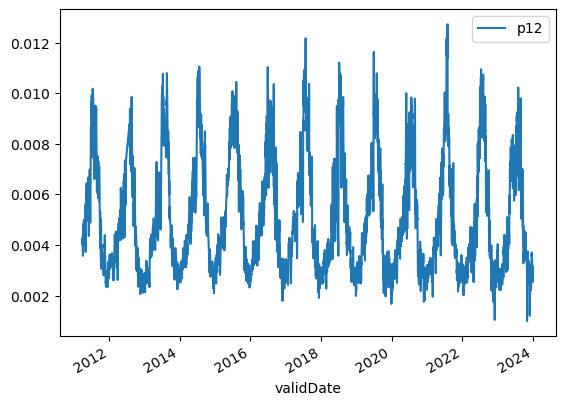

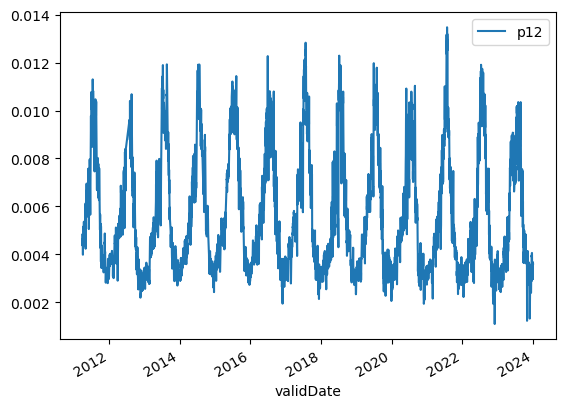

In [15]:
spha.plot(x="validDate",y="p12")
qmxa.plot(x="validDate",y="p12")


In [51]:
tmpa["validMonth"] = tmpa["validDate"].dt.month

/tmp/ipykernel_485/2243709204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmpa["validMonth"] = tmpa["validDate"].dt.month


In [34]:
tmpa["validDate"].value_counts().sort_index()

validDate
2011-04-01    1
2011-04-02    1
2011-04-03    1
2011-04-04    1
2011-04-05    1
             ..
2023-12-27    1
2023-12-28    1
2023-12-29    1
2023-12-30    1
2023-12-31    1
Name: count, Length: 4203, dtype: int64

In [38]:
tmpa.shape

(4203, 45)

In [10]:
print(tmpa.shape)
print(tmna.shape)
print(tmxa.shape)


(4203, 45)
(4203, 45)
(4203, 45)


In [48]:
p = tmpa.loc[(tmpa["validDate"].astype(str) >=  "2016-01-01") & (tmpa["validDate"].astype(str) <=  "2016-12-31")]
x = tmxa.loc[(tmxa["validDate"].astype(str) >=  "2016-01-01") & (tmxa["validDate"].astype(str) <=  "2016-12-31")]
n = tmna.loc[(tmna["validDate"].astype(str) >=  "2016-01-01") & (tmna["validDate"].astype(str) <=  "2016-12-31")]

for col in ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7',
       'p8', 'p9', 'p10', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16', 'p17',
       'p18', 'p19', 'p20', 'p21', 'p22', 'p23', 'p24', 'p25', 'p26', 'p27',
       'p28', 'p29', 'p30', 'p31', 'p32']:
       p[col]=p[col].map(K2F)
       x[col]=x[col].map(K2F)
       n[col]=n[col].map(K2F)
    
      


/tmp/ipykernel_485/1821321860.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p[col]=p[col].map(K2F)
/tmp/ipykernel_485/1821321860.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col]=x[col].map(K2F)
/tmp/ipykernel_485/1821321860.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

In [43]:
p["validDate"].value_counts().sort_index()

validDate
2016-01-01    1
2016-01-02    1
2016-01-03    1
2016-01-04    1
2016-01-05    1
             ..
2016-12-27    1
2016-12-28    1
2016-12-29    1
2016-12-30    1
2016-12-31    1
Name: count, Length: 365, dtype: int64

<Axes: xlabel='validDate'>

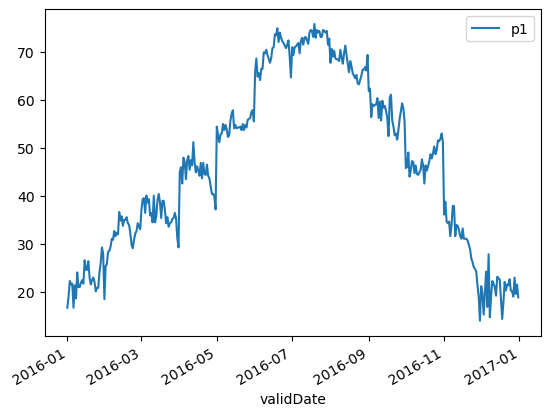

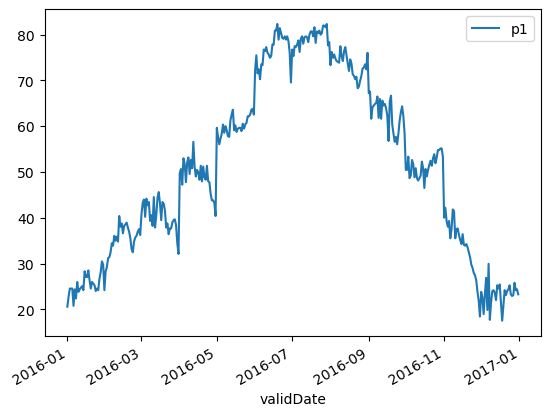

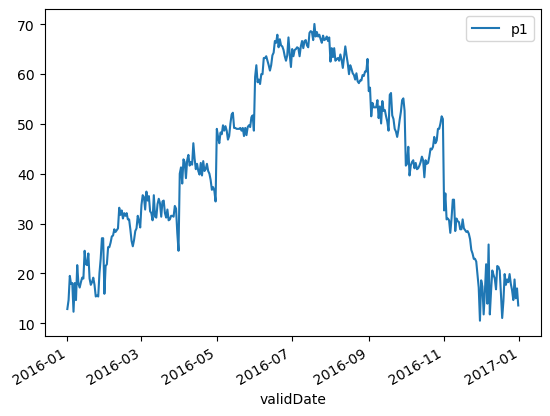

In [49]:
#p["p1"].plot()
p.plot(x="validDate",y="p1")
x.plot(x="validDate",y="p1")
n.plot(x="validDate",y="p1")

# n["p1"].plot()


In [13]:
p = tmpa.loc[(tmpa["validDate"].astype(str) >=  "2016-01-18") & (tmpa["validDate"].astype(str) <=  "2016-01-28")]
x = tmxa.loc[(tmxa["validDate"].astype(str) >=  "2016-01-18") & (tmxa["validDate"].astype(str) <=  "2016-01-28")]
n = tmna.loc[(tmna["validDate"].astype(str) >=  "2016-01-18") & (tmna["validDate"].astype(str) <=  "2016-01-28")]

for col in ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7',
       'p8', 'p9', 'p10', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16', 'p17',
       'p18', 'p19', 'p20', 'p21', 'p22', 'p23', 'p24', 'p25', 'p26', 'p27',
       'p28', 'p29', 'p30', 'p31', 'p32']:
       p[col]=p[col].map(K2F)
       x[col]=x[col].map(K2F)
       n[col]=n[col].map(K2F)
    

/tmp/ipykernel_485/3139268292.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p[col]=p[col].map(K2F)
/tmp/ipykernel_485/3139268292.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col]=x[col].map(K2F)
/tmp/ipykernel_485/3139268292.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

In [14]:
n.shape

(11, 45)

<Axes: >

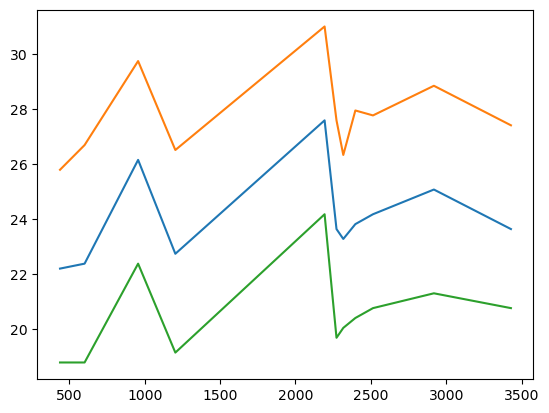

In [34]:
p["p20"].plot()
x["p20"].plot()
n["p20"].plot()


In [13]:
b = anls.loc[(anls["validDate"].astype(str) ==  "2016-06-23") ] 

In [14]:
b["p1"].values[0]

295.5

In [5]:
def K2F(K):
       return (K - 273.15) * 9/5 + 32
# for col in ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7',
#        'p8', 'p9', 'p10', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16', 'p17',
#        'p18', 'p19', 'p20', 'p21', 'p22', 'p23', 'p24', 'p25', 'p26', 'p27',
#        'p28', 'p29', 'p30', 'p31', 'p32']:
#        print(col,K2F(b[col].values[0]),K2F(a[col].min()),K2F(a[col].max()),K2F(a[col].mean()))
      

In [30]:
col="p1"
a[col].std()

0.6668787541429744

In [33]:
b = a[col].min(),a[col].max(),a[col].mean(),a[col].std()

In [34]:
b

(299.0, 301.1, 299.75454545454545, 0.6668787541429744)

In [35]:
for val in b:
    print(val)

299.0
301.1
299.75454545454545
0.6668787541429744


# Weather Station Data

## Station List

In [ ]:
fin = open("ghcnd-stations.txt")
stations = {}
for line in fin:
    spl = line.split("\t")
    # lat = spl[1]
    # lon = spl[2]
    
    id = line[:11]
    lat = line[12:20]
    lon = line[21:30]
    elv = line[30:37]
    stat = line[38:40]
    name = line[41:].replace("\n","")
    if stat == "CO":
        print(stat,line)
        stations[id]={}
        stations[id]['lat']=lat
        stations[id]['lon']=lon
        stations[id]['lev']=elv
        stations[id]['state']=stat
        stations[id]['name']=name
        

In [ ]:
          1         2         3         4         5
012345678901234567890123456789012345678901234567890
US1AZPM0202  32.2824 -110.7683  819.6 AZ TUCSON 9.9 ENE  

In [ ]:
          1         2         3         4         5
012345678901234567890123456789012345678901234567890
ACW00011604  17.1167  -61.7833 TMAX 1949 1949

In [ ]:
stations

## Station Inventory

In [72]:
fin = open("ghcnd-inventory.txt")
parmInv = {}
for line in fin:
    
    id = line[:11].strip()
    lat = line[12:20]
    lon = line[21:30]
    parm = line[31:35]
    start = line[36:40]
    end = line[41:45]
    if int(end) >= 2020 and int(start) <= 2011: 
        if id not in parmInv:
            parmInv[id]={}
        parmInv[id][parm]={}
        parmInv[id][parm]["start"]=start
        parmInv[id][parm]["end"]=end
      
    

In [ ]:
parmInv

In [73]:
byVar={}
# byVar[parm][station][lat]
# byVar[parm][station][lon]
# byVar[parm][station][lev]
# byVar[parm][station][start]
# byVar[parm][station][end]


for station,dct in stations.items():
    if station in parmInv:
       for parm,dctp in parmInv[station].items():
           if parm not in byVar:
               byVar[parm]={}
           if station not in byVar[parm]:
               byVar[parm][station]={}
          
           byVar[parm][station]["lat"]=dct["lat"]
           byVar[parm][station]["lon"]=dct["lon"]
           byVar[parm][station]["lev"]=dct["lev"]
           byVar[parm][station]["start"]=dctp["start"]
           byVar[parm][station]["end"]=dctp["end"]
           
           
        
        

In [74]:
byVar.keys()

dict_keys(['PRCP', 'SNOW', 'SNWD', 'DAPR', 'MDPR', 'WESD', 'WESF', 'WT01', 'WT03', 'WT05', 'WT11', 'TMAX', 'TMIN', 'TOBS', 'AWND', 'EVAP', 'MNPN', 'MXPN', 'WDMV', 'WT04', 'WT06', 'WDFG', 'WSFG', 'TAVG', 'PGTM', 'WDF2', 'WDF5', 'WSF2', 'WSF5', 'WT02', 'WT08', 'ADPT', 'ASLP', 'ASTP', 'AWBT', 'RHAV', 'RHMN', 'RHMX', 'WT07', 'WT09', 'WT10'])

In [ ]:
byVar

In [ ]:
for id in stations:
    if id in parmInv: 
       print(f'{stations[id]["name"]}  {stations[id]["lev"]}')
       for parm,dct in parmInv[id].items():
           dfs = int(dct["end"]) - int(dct["start"])
           if dfs > 9:
               print(f'    {parm}  {dct["start"]}  {dct["end"]}')

In [ ]:
parmInv

In [17]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    """
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of earth in kilometers. Use 3956 for miles
    return c * r

In [3]:
latlons = pd.read_csv("latLons.csv")

In [20]:
hist={}
p=0
for ix,row in latlons.iterrows():
    lat=row['Lat']
    lon=row['Lon']
    hist[p]={}
  

    for station,dct in stations.items():
        slat = float(dct['lat'])
        slon = 360+float(dct['lon'])
        dist = haversine(lat,lon,slat,slon) 
        hist[p][station]={}
        hist[p][station]['dist']=dist
        
    p+=1    
        

In [ ]:
hist

In [3]:
latlons = pd.read_csv("latLons.csv")

In [13]:
lats = latlons["Lat"].values
lons = latlons["Lon"].values


In [14]:

X,Y = np.meshgrid(lons,lats)

In [77]:
parm="TMAX" 
xlt=[]
xln=[]

for lat,lon in latlons[["Lat","Lon"]].values:
    nrec=0
    for station,dct in byVar[parm].items():
        nrec+=1
        
        latp = float(dct["lat"])
        lonp = 360+float(dct["lon"])
        dist = haversine(lat,lon,latp,lonp)
        if nrec == 1:
            minDist=dist
       
        if dist < minDist:
            minDist=dist
            latmin=latp
            lonmin=lonp
            stat=station
    xlt.append(latmin)
    xln.append(lonmin)
    
    print(lat,lon,minDist,latmin,lonmin,stat)

40.15731379530128 251.2496501305483 7.843101382232299 40.0889 251.22719999999998 USC00056832
40.15731379530128 252.1871488250653 14.100359070861755 40.0444 252.11169999999998 USW00094050
40.15731379530128 253.12464751958225 3.0396753287386082 40.1564 253.0889 USC00059265
40.15731379530128 254.0621462140992 6.334731213810025 40.1819 254.1294 USC00053500
40.15731379530128 254.9996449086162 6.691815149018185 40.1694 254.9225 USC00055116
40.15731379530128 255.9371436031332 19.769881527992112 40.2569 256.13 USC00053038
40.15731379530128 256.8746422976501 1.412481946898412 40.2569 256.13 USC00053038
40.15731379530128 257.8121409921671 8.540503943007597 40.0819 257.7931 USC00059243
39.2124374010912 251.2496501305483 7.80472058817438 39.1444 251.27190000000002 USC00053146
39.2124374010912 252.1871488250653 14.299789432316622 39.1025 252.1011 USC00050825
39.2124374010912 253.12464751958225 1.9953231731164833 39.23 253.1294 USW00093073
39.2124374010912 254.0621462140992 4.916384804880448 39.2219

In [ ]:
byVar

In [66]:
xlats=[]
xlons=[]
parm="TMAX"

for station,dct in byVar[parm].items():
    if int(dct["start"]) <= 2011:
        xlats.append(float(dct["lat"]))
        xlons.append(float(dct["lon"]))
              

In [ ]:
xlats

In [79]:
latmin=latlons["Lat"].min()
latmax=latlons["Lat"].max()
lonmin=latlons["Lon"].min()
lonmax=latlons["Lon"].max()

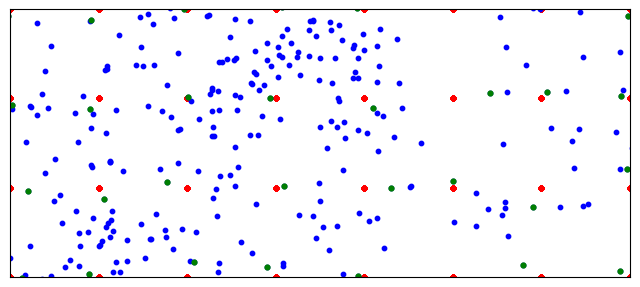

In [80]:
fig = plt.figure(figsize=(8, 6), edgecolor='b')

my_map = Basemap(projection='cyl',
               llcrnrlat=latmin, urcrnrlat=latmax,resolution="l",
            llcrnrlon=lonmin, urcrnrlon=lonmax)
 
#my_map.drawcoastlines()
my_map.drawstates()
my_map.scatter(X, Y, latlon=True,c="red",s=10)
my_map.scatter(xlons, xlats, latlon=True,c="blue",s=10)
my_map.scatter(xln, xlt, latlon=True,c="green",s=12)


#my_map.contour(X,Y,data.reshape(4,8))

## Global Summary of the Day (GSOD)

In [8]:
df = pd.read_csv("gsod.csv")

In [10]:
df.head()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TMAX,TMIN
0,USR0000CCOT,"COTTONWOOD BASIN COLORADO, CO US",38.5731,-108.2778,2200.7,2011-01,38.7,13.6
1,USR0000CCOT,"COTTONWOOD BASIN COLORADO, CO US",38.5731,-108.2778,2200.7,2011-02,38.6,16.2
2,USR0000CCOT,"COTTONWOOD BASIN COLORADO, CO US",38.5731,-108.2778,2200.7,2011-03,51.2,30.7
3,USR0000CCOT,"COTTONWOOD BASIN COLORADO, CO US",38.5731,-108.2778,2200.7,2011-04,55.3,31.8
4,USR0000CCOT,"COTTONWOOD BASIN COLORADO, CO US",38.5731,-108.2778,2200.7,2011-05,63.2,38.8


### Put GSOD Into Dict

In [11]:
histTmax={}
histTmin={}

for index,row in df.iterrows():
    station = row['STATION']
    date = row['DATE']
    year = int(date[:4])
    month = int(date[5:])
    tmax = float(row["TMAX"])
    tmin = float(row["TMIN"])
    if not math.isnan(float(tmin)):
        if station not in histTmin:
            histTmin[station]={}
        if year not in histTmin[station]:
            histTmin[station][year]={}
            histTmin[station]["lat"]=row["LATITUDE"]
            histTmin[station]["lon"]= row["LONGITUDE"]
            histTmin[station]["elv"]= row["ELEVATION"]
            
            
        if month not in histTmin[station][year]:
            histTmin[station][year][month]=0
        histTmin[station][year][month]+=1


    if not math.isnan(float(tmax)):
            if station not in histTmax:
                histTmax[station]={}
                histTmax[station]["count"]={}
                histTmax[station]["lat"]=row["LATITUDE"]
                histTmax[station]["lon"]= row["LONGITUDE"]
                histTmax[station]["elv"]= row["ELEVATION"]
                
                
            if year not in histTmax[station]["count"]:             
                histTmax[station]["count"][year]={}             
                
            if month not in histTmax[station]["count"][year]:
                histTmax[station]["count"][year][month]=0
            histTmax[station]["count"][year][month]+=1
                
        
    

### Compute # of Months Per Year Per Station

In [12]:
hist={}
for station,dct in histTmax.items():
    nyears=0
    for yr,dct2 in dct["count"].items():
       nmonths=0
       for mo,cnt in dct2.items():
           if cnt > 0:
               nmonths+=1
       if nmonths > 9: 
          nyears+=1
       if station not in hist:
            hist[station]={}
            hist[station]["lat"]=histTmax[station]["lat"]
            hist[station]["lon"]=histTmax[station]["lon"]
            hist[station]["elv"]=histTmax[station]["elv"]
           
           
       hist[station][yr]=nmonths


histBest={}
for station,dct in hist.items():
    nyrs=0
    for yr,cnt in dct.items():
        if cnt >= 8:
            nyrs+=1
        if nyrs >= 10:
            histBest[station]={}
            histBest[station]['lat']=dct['lat']
            histBest[station]['lon']=dct['lon']
            histBest[station]['elv']=dct['elv']
            
            histBest[station]['nyears']=nyrs
            
           

### Get Model Lat-Lons

In [13]:
latlons = pd.read_csv("latLons.csv")

In [14]:
def matpElevs(row):
    i=int(row["I"])+1
    j=int(row["J"])
    elv=elevs[j][i]["elv"]
    return elv

latlons["elv"]=latlons.apply(matpElevs,axis=1)
    

### Get Closest GSOD Station to Model Points

In [15]:
stats={}
for index,row in latlons.iterrows():
    lat=row["Lat"]
    lon=row["Lon"]
    nrec=0
    for station,dct in histBest.items():
        nrec+=1
        latd = dct["lat"]
        lond = dct["lon"]
        
        dist = haversine(lat,lon,latd,lond)
        
        if nrec==1:
            distMin=dist
            stationMin=station
        if dist < distMin:
            distMin=dist
            stationMin=station
    stats[f"p{index+1}"]={}
    stats[f"p{index+1}"]["station"]=stationMin
    stats[f"p{index+1}"]["elv"]=histBest[stationMin]["elv"]*3.28084
    
    stats[f"p{index+1}"]["dist"]=distMin
 #   print(latlons.loc[index,"elv"])
    stats[f"p{index+1}"]["modelv"]=latlons.loc[index,"elv"]
            

In [16]:
stats

{'p1': {'station': 'USC00056832',
  'elv': 5276.903056,
  'dist': 7.84103634348643,
  'modelv': 7541.666908000001},
 'p2': {'station': 'USW00094050',
  'elv': 6367.454272,
  'dist': 14.105652945422198,
  'modelv': 8777.559336},
 'p3': {'station': 'USC00059265',
  'elv': 7854.987128,
  'dist': 3.0341665125420283,
  'modelv': 8765.092144000002},
 'p4': {'station': 'USC00053500',
  'elv': 8290.026512,
  'dist': 6.3346361115606475,
  'modelv': 7210.302068000001},
 'p5': {'station': 'USC00050950',
  'elv': 5024.934544,
  'dist': 27.69400011646276,
  'modelv': 5273.294132000001},
 'p6': {'station': 'USC00053038',
  'elv': 4375.984391999999,
  'dist': 19.78151444598475,
  'modelv': 4089.8951440000005},
 'p7': {'station': 'USC00050109',
  'elv': 4541.994896,
  'dist': 1.4194496195550124,
  'modelv': 3653.871508},
 'p8': {'station': 'USC00059243',
  'elv': 3553.14972,
  'dist': 8.529950501235993,
  'modelv': 3292.32294},
 'p9': {'station': 'USC00051772',
  'elv': 5780.84008,
  'dist': 12.440029

### Add GSOD to Compare Dict

In [17]:
compares={}

for pp,dct in stats.items():
    station=dct["station"]
    print(pp,station)
    tmp = df.loc[(df["STATION"] == station)]
    compares[pp]={}
    compares[pp][station]={}
    for index,row in tmp.iterrows():
        yrmo = row["DATE"]
        compares[pp][station][yrmo]=row["TMAX"]

p1 USC00056832
p2 USW00094050
p3 USC00059265
p4 USC00053500
p5 USC00050950
p6 USC00053038
p7 USC00050109
p8 USC00059243
p9 USC00051772
p10 USC00050825
p11 USW00093073
p12 USC00052816
p13 USC00055733
p14 USW00093010
p15 USC00052932
p16 USW00003026
p17 USR0000CNUC
p18 USC00057020
p19 USR0000CHUM
p20 USS0005L12S
p21 USC00056765
p22 USC00058157
p23 USC00054834
p24 USC00057586
p25 USW00093069
p26 USR0000CLOG
p27 USS0006M17S
p28 USC00058860
p29 USS0005M07S
p30 USW00023070
p31 USC00054538
p32 USC00058793


### Add Model Data to Compare Dict

In [18]:
vrs = ["p1","p2","p3","p4","p5","p6","p7","p8","p9","p10","p11","p12","p13","p14","p15","p16","p17","p18","p19","p20","p21","p22","p23","p24","p25","p26","p27","p28","p29","p30","p31","p32"]

for indx,row in tmx.iterrows():
    date=row["forecastDate"]
    adate=row["validDate"]
    if adate == date: 
    #    print(adate,date)
        for pp in vrs:
            tmax = row[pp]
            if "model" not in compares[pp]:
                compares[pp]["model"]={}
            compares[pp]["model"][date] = {}
            compares[pp]["model"][date]["value"]=tmax
            compares[pp]["model"][date]["analdate"]=row["validDate"]
            
    

In [19]:
vrs = ["p1","p2","p3","p4","p5","p6","p7","p8","p9","p10","p11","p12","p13","p14","p15","p16","p17","p18","p19","p20","p21","p22","p23","p24","p25","p26","p27","p28","p29","p30","p31","p32"]

for indx,row in tmx.iterrows():
    date=row["forecastDate"]
    adate=row["validDate"]
    tbin = row['valueOfForecastTime']
    for pp in vrs:
        tmax = row[pp]
        if "modelf" not in compares[pp]:
            compares[pp]["modelf"]={}
        # compares[pp]["model"][date] = {}
        # compares[pp]["model"][date]["value"]=tmax
        # compares[pp]["model"][date]["analdate"]=row["validDate"]'
        if tbin not in compares[pp]["modelf"]:
            compares[pp]["modelf"][tbin]={}
        compares[pp]["modelf"][tbin][date] = {}
        compares[pp]["modelf"][tbin][date]["value"]=tmax
        compares[pp]["modelf"][tbin][date]["analdate"]=row["validDate"]
            

In [ ]:
compares["p1"]["modelf"]

In [105]:
tmx.head()

,index,file,refDate,typeOfData,fullName,shortName,paramNum,units,validDate,forecastDate,valueOfForecastTime,unitOfForecastTime,level,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,p11,p12,p13,p14,p15,p16,p17,p18,p19,p20,p21,p22,p23,p24,p25,p26,p27,p28,p29,p30,p31,p32
0,6,flxf.01.2016080400.201703.avrg.grib.grb2,2016-08-04,1 - Forecast Products,Maximum Temperature,TMAX,4,K,2016-08-04,2017-03-04,7,3 - Month,2 m above ground,278.2,276.2,272.9,273.4,276.5,279.3,280.0,279.2,278.9,275.5,271.8,272.9,276.9,280.0,280.7,279.9,279.3,275.2,271.6,273.3,277.6,280.9,281.5,280.8,280.5,277.0,274.4,275.0,278.2,280.9,281.8,281.7
1,6,flxf.01.2016071800.201703.avrg.grib.grb2,2016-07-18,1 - Forecast Products,Maximum Temperature,TMAX,4,K,2016-07-18,2017-03-18,8,3 - Month,2 m above ground,278.2,276.5,273.5,273.6,276.5,279.6,281.1,281.2,278.6,275.6,272.1,272.8,276.5,279.8,281.4,281.6,278.7,274.9,271.3,272.7,276.6,280.1,281.7,282.1,279.8,276.3,273.6,273.9,276.6,279.6,281.5,282.4
2,6,flxf.01.2016042600.201611.avrg.grib.grb2,2016-04-26,1 - Forecast Products,Maximum Temperature,TMAX,4,K,2016-04-26,2016-11-26,7,3 - Month,2 m above ground,273.7,272.2,269.9,270.6,273.8,276.6,277.6,277.2,274.3,271.8,269.1,270.8,274.7,277.7,278.8,278.4,275.1,271.9,269.3,271.5,275.8,279.1,280.2,280.0,276.9,273.7,271.5,273.3,276.4,279.5,281.2,281.8
3,6,flxf.01.2016121200.201704.avrg.grib.grb2,2016-12-12,1 - Forecast Products,Maximum Temperature,TMAX,4,K,2016-12-12,2017-04-12,4,3 - Month,2 m above ground,277.8,275.6,272.2,273.3,277.0,280.3,281.6,281.3,278.2,274.5,270.4,272.5,277.3,281.1,282.6,282.5,278.8,274.2,270.5,272.9,278.2,282.3,284.0,284.2,280.6,276.6,273.7,275.2,279.0,282.7,284.7,285.7
4,6,flxf.01.2016051600.201702.avrg.grib.grb2,2016-05-16,1 - Forecast Products,Maximum Temperature,TMAX,4,K,2016-05-16,2017-02-16,9,3 - Month,2 m above ground,273.6,271.8,268.7,269.8,272.6,275.0,275.8,275.4,274.5,271.5,268.0,269.9,273.4,275.9,276.5,276.1,274.7,270.8,268.2,270.1,274.0,276.7,277.2,276.9,276.1,272.8,270.0,271.4,274.2,276.5,277.5,277.7


In [41]:
tmx.columns

Index(['index', 'file', 'refDate', 'typeOfData', 'fullName', 'shortName',
       'paramNum', 'units', 'validDate', 'forecastDate', 'valueOfForecastTime',
       'unitOfForecastTime', 'level', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7',
       'p8', 'p9', 'p10', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16', 'p17',
       'p18', 'p19', 'p20', 'p21', 'p22', 'p23', 'p24', 'p25', 'p26', 'p27',
       'p28', 'p29', 'p30', 'p31', 'p32'],
      dtype='object')

In [43]:
tmx[['validDate','forecastDate','valueOfForecastTime']]

,validDate,forecastDate,valueOfForecastTime
0,2016-08-04,2017-03-04,7
1,2016-07-18,2017-03-18,8
2,2016-04-26,2016-11-26,7
3,2016-12-12,2017-04-12,4
4,2016-05-16,2017-02-16,9
...,...,...,...
45263,2015-12-31,2016-05-31,5
45264,2015-12-31,2016-06-30,6
45265,2015-12-31,2016-07-31,7
45266,2015-12-31,2016-08-31,8


In [44]:
tmx['valueOfForecastTime'].value_counts()

valueOfForecastTime
5    4565
7    4564
8    4564
4    4564
9    4563
1    4562
6    4562
2    4561
3    4560
0    4203
Name: count, dtype: int64

### Analyze Model vs GSOD

In [106]:
means={}
meansbyDay={}
meansbyMon={}
for pp in compares:
    print(pp)
    stn=list(compares[pp].keys())[0]
    means[pp]={}
    means[pp]["sum"]=0
    means[pp]["count"]=0
    meansbyMon[pp]={}
    meansbyDay[pp]={}
    
 
    means[pp]["elvDiff"] = stats[pp]["elv"] - stats[pp]["modelv"]
    means[pp]["dist"] = stats[pp]["dist"]
    for date,dct in sorted(compares[pp]["model"].items()):
        tmaxK=dct["value"]
        adate=dct["analdate"]
        tmaxF=K2F(tmaxK)
        fdate=date[:7]
        if date == adate: 
            mon = date[5:7]
            day= int(date[8:10])
            nbin = int(day/5) 
            
      #      print(date,fdate,mon,day)
            
            if fdate in compares[pp][stn]:
                tmaxObs=compares[pp][stn][fdate]
                if not math.isnan(tmaxObs) and not math.isnan(tmaxF):
                    diff=tmaxF-tmaxObs
                    means[pp]["sum"]+=abs(diff)
                    means[pp]["count"]+=1
                    if mon not in meansbyMon[pp]:
                           meansbyMon[pp][mon]={}
                           meansbyMon[pp][mon]["sum"]=0
                           meansbyMon[pp][mon]["count"]=0
                    meansbyMon[pp][mon]["sum"]+=abs(diff)
                    meansbyMon[pp][mon]["count"]+=1
                    if nbin not in meansbyDay[pp]:
                           meansbyDay[pp][nbin]={}
                           meansbyDay[pp][nbin]["sum"]=0
                           meansbyDay[pp][nbin]["count"]=0
                    meansbyDay[pp][nbin]["sum"]+=abs(diff)
                    meansbyDay[pp][nbin]["count"]+=1
                    
                
          #      print(pp,stats[pp]["dist"],stats[pp]["elv"],stats[pp]["modelv"],date,fdate,adate,tmaxF,tmaxObs,diff)
                

p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19
p20
p21
p22
p23
p24
p25
p26
p27
p28
p29
p30
p31
p32


### New Analysis

In [ ]:
means={}
meansbyDay={}
meansbyMon={}
for pp in compares:
    print(pp)
    stn=list(compares[pp].keys())[0]
    means[pp]={}
    means[pp]["sum"]=0
    means[pp]["count"]=0
    meansbyMon[pp]={}
    meansbyDay[pp]={}
    
 
    means[pp]["elvDiff"] = stats[pp]["elv"] - stats[pp]["modelv"]
    means[pp]["dist"] = stats[pp]["dist"]
    for tbin,dct in sorted(compares[pp]["modelf"].items()):
       for date,dct2 in sorted(dct.items()):
        
            tmaxK=dct2["value"]
            adate=dct2["analdate"]
            tmaxF=K2F(tmaxK)
            fdate=date[:7]
            if date == date: 
                mon = date[5:7]
                day= int(date[8:10])
                nbin = int(day/5)                 
                if fdate in compares[pp][stn]:
                    tmaxObs=compares[pp][stn][fdate]
                    if not math.isnan(tmaxObs) and not math.isnan(tmaxF):
                        diff=tmaxF-tmaxObs
                        print(pp,tbin,stn,date,fdate,tmaxF,tmaxObs,diff)
                        means[pp]["sum"]+=abs(diff)
                        means[pp]["count"]+=1
                        if tbin not in meansbyMon[pp]:
                            meansbyMon[pp][tbin]={}
                            
                        if mon not in meansbyMon[pp][tbin]:
                               meansbyMon[pp][tbin][mon]={}
                               meansbyMon[pp][tbin][mon]["sum"]=0
                               meansbyMon[pp][tbin][mon]["count"]=0
                        meansbyMon[pp][tbin][mon]["sum"]+=abs(diff)
                        meansbyMon[pp][tbin][mon]["count"]+=1
                        if nbin not in meansbyDay[pp]:
                               meansbyDay[pp][nbin]={}
                               meansbyDay[pp][nbin]["sum"]=0
                               meansbyDay[pp][nbin]["count"]=0
                        meansbyDay[pp][nbin]["sum"]+=abs(diff)
                        meansbyDay[pp][nbin]["count"]+=1
                    
    break            
          #      print(pp,stats[pp]["dist"],stats[pp]["elv"],stats[pp]["modelv"],date,fdate,adate,tmaxF,tmaxObs,diff)
                

In [ ]:
meansbyMon

In [34]:
for pp,dct in means.items():
    mean = means[pp]["sum"]/means[pp]["count"]
    print(pp,mean,means[pp]["dist"],means[pp]["elvDiff"])

p1 12.556257846450988 7.84103634348643 -2264.763852000001
p2 13.986036164644263 14.105652945422198 -2410.1050640000003
p3 12.936365612170984 3.0341665125420283 -910.1050160000023
p4 9.05827012478587 6.3346361115606475 1079.7244439999995
p5 16.99228408279801 27.69400011646276 -248.35958800000117
p6 11.405173259736276 19.78151444598475 286.08924799999886
p7 8.561984659635652 1.4194496195550124 888.123388
p8 9.98482126204535 8.529950501235993 260.82677999999987
p9 14.076754645838914 12.44002913271669 -2243.438392000001
p10 3.6844000000000143 14.29531779149771 431.4304599999996
p11 16.917470854151773 1.9902239850034038 -1574.4751160000005
p12 6.805489833641361 4.9148132345534625 2458.9895800000004
p13 12.809240735161145 20.751651761304842 1451.1155319999998
p14 9.275258329309512 34.7244911105861 1182.086651999999
p15 8.780674888660473 9.40310234468199 1204.3963640000006
p16 9.215532424024827 8.721995699353654 917.6509480000004
p17 14.446159885795854 17.29106786556287 -2433.7271120000005
p1

In [ ]:
for pp,dct in meansbyMon.items():
    print(pp)
    for mon,dct2 in sorted(dct.items()):
        print(f"   {mon}  {dct2['count']}  {dct2['sum']/dct2['count']}" )

In [ ]:
for pp,dct in meansbyDay.items():
    print(pp)
    for nbin,dct2 in sorted(dct.items()):
        print(f"   {nbin}  {dct2['count']}  {dct2['sum']/dct2['count']}" )

In [33]:
print(len(compares["p1"]['USC00056832']) )
print(len(compares["p1"]['model']) )


156
4925


In [127]:
vrs = ["p1","p2","p3","p4","p5","p6","p7","p8","p9","p10","p11","p12","p13","p14","p15","p16","p17","p18","p19","p20","p21","p22","p23","p24","p25","p26","p27","p28","p29","p30","p31","p32"]

xx=[]
yy=[]
pts=[]
dif=[]
days=[]
months=[]
for pp in vrs: 
    stn=list(compares[pp].keys())[0]
    start = sorted(compares[pp]['model'].keys())[0]
    end = sorted(compares[pp]['model'].keys())[-1]
    print(start,end)
    
    start=datetime.datetime.strptime(start,"%Y-%m-%d")
    print(type(start))
    end=datetime.datetime.strptime(end,"%Y-%m-%d")
    
    ndays=end-start
    print(type(ndays),ndays.days)
    date=start
    print(pp,start,end,ndays)
    for nday in range(ndays.days):
     #   print(nday,date)
        datestr = datetime.datetime.strftime(date,"%Y-%m-%d")[:10]
        yrmo = datetime.datetime.strftime(date,"%Y-%m-%d")[:7]
        mon = date.month
        day = date.day
        
      #  print(nday,yrmo,datestr)
        if datestr in compares[pp]["model"]:
           value = compares[pp]["model"][datestr]["value"]
           value=K2F(value)
           if datestr[:7] in compares[pp][stn]:
              obs = compares[pp][stn][datestr[:7]]
           else:
              obs = math.nan 
        else:
           value = math.nan
        xx.append(datestr)
        yy.append(value)
        days.append(day)
        months.append(mon)
        if not math.isnan(value) and not math.isnan(obs):
            d= obs-value
        else:
            d= math.nan 
        dif.append(d) 
        pts.append(pp)
        date = date + relativedelta(days=1)

#tdate = datetime.date(year,month,int(dy))
#adate = tdate + relativedelta(days=nd)


# for date,dct in sorted(compares["p1"]['model'].items()):
#     print(date,dct["value"])
    

2011-04-01 2023-12-31
<class 'datetime.datetime'>
<class 'datetime.timedelta'> 4657
p1 2011-04-01 00:00:00 2023-12-31 00:00:00 4657 days, 0:00:00
2011-04-01 2023-12-31
<class 'datetime.datetime'>
<class 'datetime.timedelta'> 4657
p2 2011-04-01 00:00:00 2023-12-31 00:00:00 4657 days, 0:00:00
2011-04-01 2023-12-31
<class 'datetime.datetime'>
<class 'datetime.timedelta'> 4657
p3 2011-04-01 00:00:00 2023-12-31 00:00:00 4657 days, 0:00:00
2011-04-01 2023-12-31
<class 'datetime.datetime'>
<class 'datetime.timedelta'> 4657
p4 2011-04-01 00:00:00 2023-12-31 00:00:00 4657 days, 0:00:00
2011-04-01 2023-12-31
<class 'datetime.datetime'>
<class 'datetime.timedelta'> 4657
p5 2011-04-01 00:00:00 2023-12-31 00:00:00 4657 days, 0:00:00
2011-04-01 2023-12-31
<class 'datetime.datetime'>
<class 'datetime.timedelta'> 4657
p6 2011-04-01 00:00:00 2023-12-31 00:00:00 4657 days, 0:00:00
2011-04-01 2023-12-31
<class 'datetime.datetime'>
<class 'datetime.timedelta'> 4657
p7 2011-04-01 00:00:00 2023-12-31 00:00:

In [128]:
tmp={"point":pts,"dates":xx,"values":yy,"diffs":dif,"month":months,"day":days} 
tmp=pd.DataFrame(tmp)

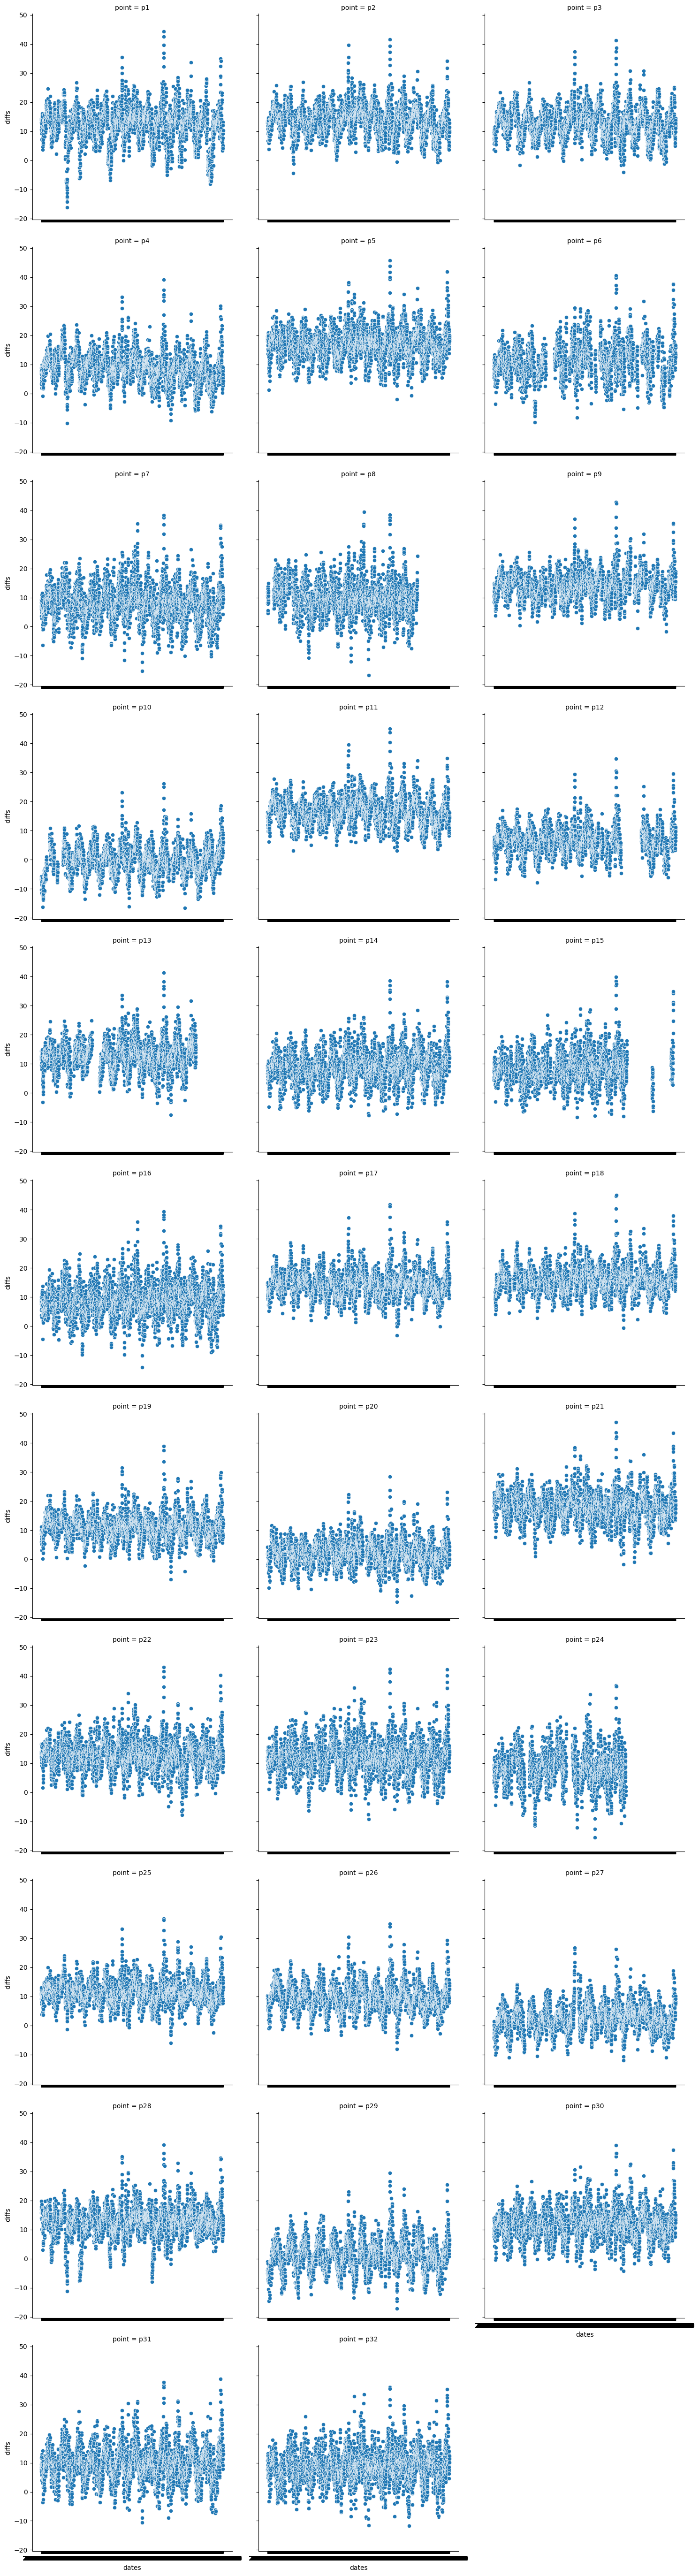

In [133]:
sns.relplot(data=tmp, x="dates", y="diffs",  col="point", col_wrap=3)

In [31]:
compares["p1"]["modelf"][0]["2016-06-11"]

{'value': 297.6, 'analdate': '2016-06-11'}

In [70]:
compares["p1"].keys()

dict_keys(['USC00056832', 'model', 'modelf'])

### A New Method

In [122]:
compares["p1"]["modelf"][0]["2016-06-11"]
pp="p1"
pts=[]
dates=[]
adates=[]
obs=[]
model=[]
tbins=[]
yrs=[]
mons=[]
days=[]
diffs=[]
stn = list(compares[pp].keys())[0]
for tbin,dct in sorted(compares[pp]["modelf"].items()):
    for date,dct2 in sorted(dct.items()):
        pts.append(pp)
        dates.append(date)
        yr=int(date[:4])
        mo=int(date[5:7])
        day=int(date[8:10]) 
        days.append(day)
        yrs.append(yr)
        mons.append(mo)
        fyrmo=date[:7]
        modelObs=K2F(dct2["value"])
        if fyrmo in compares[pp][stn]:
            tmaxObs=compares[pp][stn][fyrmo]
            if not math.isnan(tmaxObs) and not math.isnan(modelObs):
               diff=tmaxObs-modelObs
            else:
               diff=np.nan
        else:
            tmaxObs=np.nan
        diffs.append(diff)
        adates.append(dct2["analdate"])
        model.append(modelObs)
        obs.append(tmaxObs)
        tbins.append(tbin)

In [123]:
tmp = pd.DataFrame({
    "Point":pts,
    "Forecast Bin":tbins,
    "Forecast Year":yrs,
    "Forecast Month":mons,
    "Forecast Day":days,
    "Forecast Date":dates,
    "Analysis Date":adates,
    "Model":model,
    "Obs":obs,
    "Diff":diffs
})

In [124]:
tmp.columns

Index(['Point', 'Forecast Bin', 'Forecast Year', 'Forecast Month',
       'Forecast Day', 'Forecast Date', 'Analysis Date', 'Model', 'Obs',
       'Diff'],
      dtype='object')

In [125]:
tmp["Analysis Date"] = pd.to_datetime(tmp["Analysis Date"])
tmp["Forecast Date"] = pd.to_datetime(tmp["Forecast Date"])
tmp["Forecast Date"] = tmp["Forecast Date"].dt.date
tmp["Analysis Date"] = tmp["Analysis Date"].dt.date
tmp["Analysis Date"] = pd.to_datetime(tmp["Analysis Date"])
tmp["Forecast Date"] = pd.to_datetime(tmp["Forecast Date"])

In [126]:
tmp.isna().sum()

Point                0
Forecast Bin         0
Forecast Year        0
Forecast Month       0
Forecast Day         0
Forecast Date        0
Analysis Date        0
Model                0
Obs               1886
Diff               597
dtype: int64

In [24]:
tmp.shape

(44740, 10)

In [130]:
tmp.head()

,Point,Forecast Bin,Forecast Year,Forecast Month,Forecast Day,Forecast Date,Analysis Date,Model,Obs,Diff
0,p1,0,2011,4,1,2011-04-01,2011-04-01,44.51,58.5,13.99
1,p1,0,2011,4,2,2011-04-02,2011-04-02,44.51,58.5,13.99
2,p1,0,2011,4,3,2011-04-03,2011-04-03,44.15,58.5,14.35
3,p1,0,2011,4,4,2011-04-04,2011-04-04,45.41,58.5,13.09
4,p1,0,2011,4,5,2011-04-05,2011-04-05,47.93,58.5,10.57


In [135]:
tmp.groupby(["Forecast Bin","Forecast Month"])[["Model","Obs","Diff"]].mean()

Model        Obs       Diff
Forecast Bin Forecast Month                                 
0            1               26.076221  29.444186   3.367965
             2               30.064720  37.541925   7.477205
             3               40.885357  53.075738  12.011115
             4               50.711727  61.690808  10.979081
             5               61.553211  71.993803  10.440592
             6               73.402477  87.024159  13.621682
             7               78.346316  92.611111  14.264795
             8               73.885410  89.654098  15.768689
             9               63.003872  80.854407  18.000821
             10              47.482459  64.695902  17.213443
             11              34.000500  49.668333  15.667833
             12              25.557030  33.396185   7.839155
1            1               25.823134  29.489757   3.981393
             2               31.308407  37.715339   6.406932
             3               37.883982  53.299035  15.311286
             4               48.970737  61.884703  12.913966
             5               60.058483  71.971979  11.913496
             6               71.840632  86.845000  15.004368
             7               78.572978  92.477528  13.904551
             8               74.919297  89.445135  14.525838
             9               65.370515  80.804469  15.518547
             10              51.884910  64.789974  12.905064
             11              37.070619  49.522680  12.452062
             12              27.765835  33.087147   5.321311
2            1               26.437815  29.534819   3.619820
             2               31.674426  37.679525   6.279180
             3               39.204839  53.272727  14.128944
             4               47.934779  61.905310  13.970531
             5               59.193846  72.488187  13.294341
             6               71.415385  86.800000  15.384615
             7               78.926462  92.388718  13.462256
             8               75.908876  89.519944  13.611067
             9               65.553911  80.872644  15.424650
             10              51.574100  64.786500  13.212400
             11              36.529846  49.540103  13.010257
             12              27.945062  33.081047   5.135985
3            1               26.696733  29.541892   3.353292
             2               31.690870  37.715339   6.271250
             3               39.351791  53.250294  13.714744
             4               47.631500  61.900000  14.268500
             5               58.140619  72.541593  14.400973
             6               70.596232  87.047025  16.450793
             7               78.382853  92.427763  14.044910
             8               75.649538  89.572308  13.922769
             9               65.725662  80.803951  15.103739
             10              51.608811  64.677027  13.068216
             11              35.983488  49.522997  13.539509
             12              27.747326  33.075064   5.327738
4            1               26.501208  29.491667   3.444139
             2               31.486066  37.756380   6.583060
             3               39.070206  53.285714  14.015961
             4               47.467275  61.896936  14.128972
             5               57.626774  72.533333  14.906559
             6               69.476903  87.123009  17.646106
             7               77.675370  92.732055  15.056685
             8               75.097506  89.570694  14.473188
             9               65.256299  80.798006  15.627493
             10              51.513820  64.785393  13.271573
             11              35.862458  49.208939  13.346480
             12              26.901950  33.094750   6.192800
5            1               25.813400  29.548238   4.147450
             2               31.720191  37.715339   6.336322
             3               38.925511  53.284366  14.219135
             4               47.244242  61.912256  14.427224
       

In [127]:
#tmp2 = tmp.loc[(tmp["Forecast Month"] == 6) & (tmp["Forecast Bin"] ==0) ]
tmp2 = tmp.loc[ (tmp["Forecast Bin"] ==0) ]


In [128]:
tmp2

,Point,Forecast Bin,Forecast Year,Forecast Month,Forecast Day,Forecast Date,Analysis Date,Model,Obs,Diff
0,p1,0,2011,4,1,2011-04-01,2011-04-01,44.51,58.5,13.99
1,p1,0,2011,4,2,2011-04-02,2011-04-02,44.51,58.5,13.99
2,p1,0,2011,4,3,2011-04-03,2011-04-03,44.15,58.5,14.35
3,p1,0,2011,4,4,2011-04-04,2011-04-04,45.41,58.5,13.09
4,p1,0,2011,4,5,2011-04-05,2011-04-05,47.93,58.5,10.57
...,...,...,...,...,...,...,...,...,...,...
4198,p1,0,2023,12,27,2023-12-27,2023-12-27,23.63,36.8,13.17
4199,p1,0,2023,12,28,2023-12-28,2023-12-28,24.71,36.8,12.09
4200,p1,0,2023,12,29,2023-12-29,2023-12-29,26.51,36.8,10.29
4201,p1,0,2023,12,30,2023-12-30,2023-12-30,26.51,36.8,10.29


In [27]:
tmp2.dtypes

Point                     object
Forecast Bin               int64
Forecast Year              int64
Forecast Month             int64
Forecast Day               int64
Forecast Date     datetime64[ns]
Analysis Date     datetime64[ns]
Model                    float64
Obs                      float64
Diff                     float64
dtype: object

<Axes: xlabel='Forecast Date'>

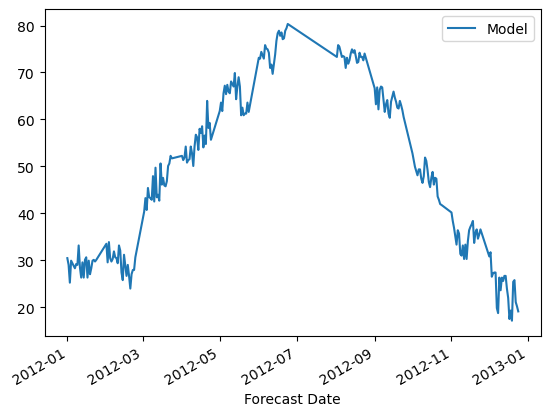

In [129]:
tmp2.loc[tmp2["Forecast Year"] == 2012].plot("Forecast Date","Model")

In [88]:
g = sns.FacetGrid(tmp2, col="Forecast Year", height=3.5, aspect=.65)
g.map(sns.scatterplot, "Forecast Date","Model")

TypeError: FacetGrid.__init__() got an unexpected keyword argument 'facet_kws'

#### Plot Forecast Data

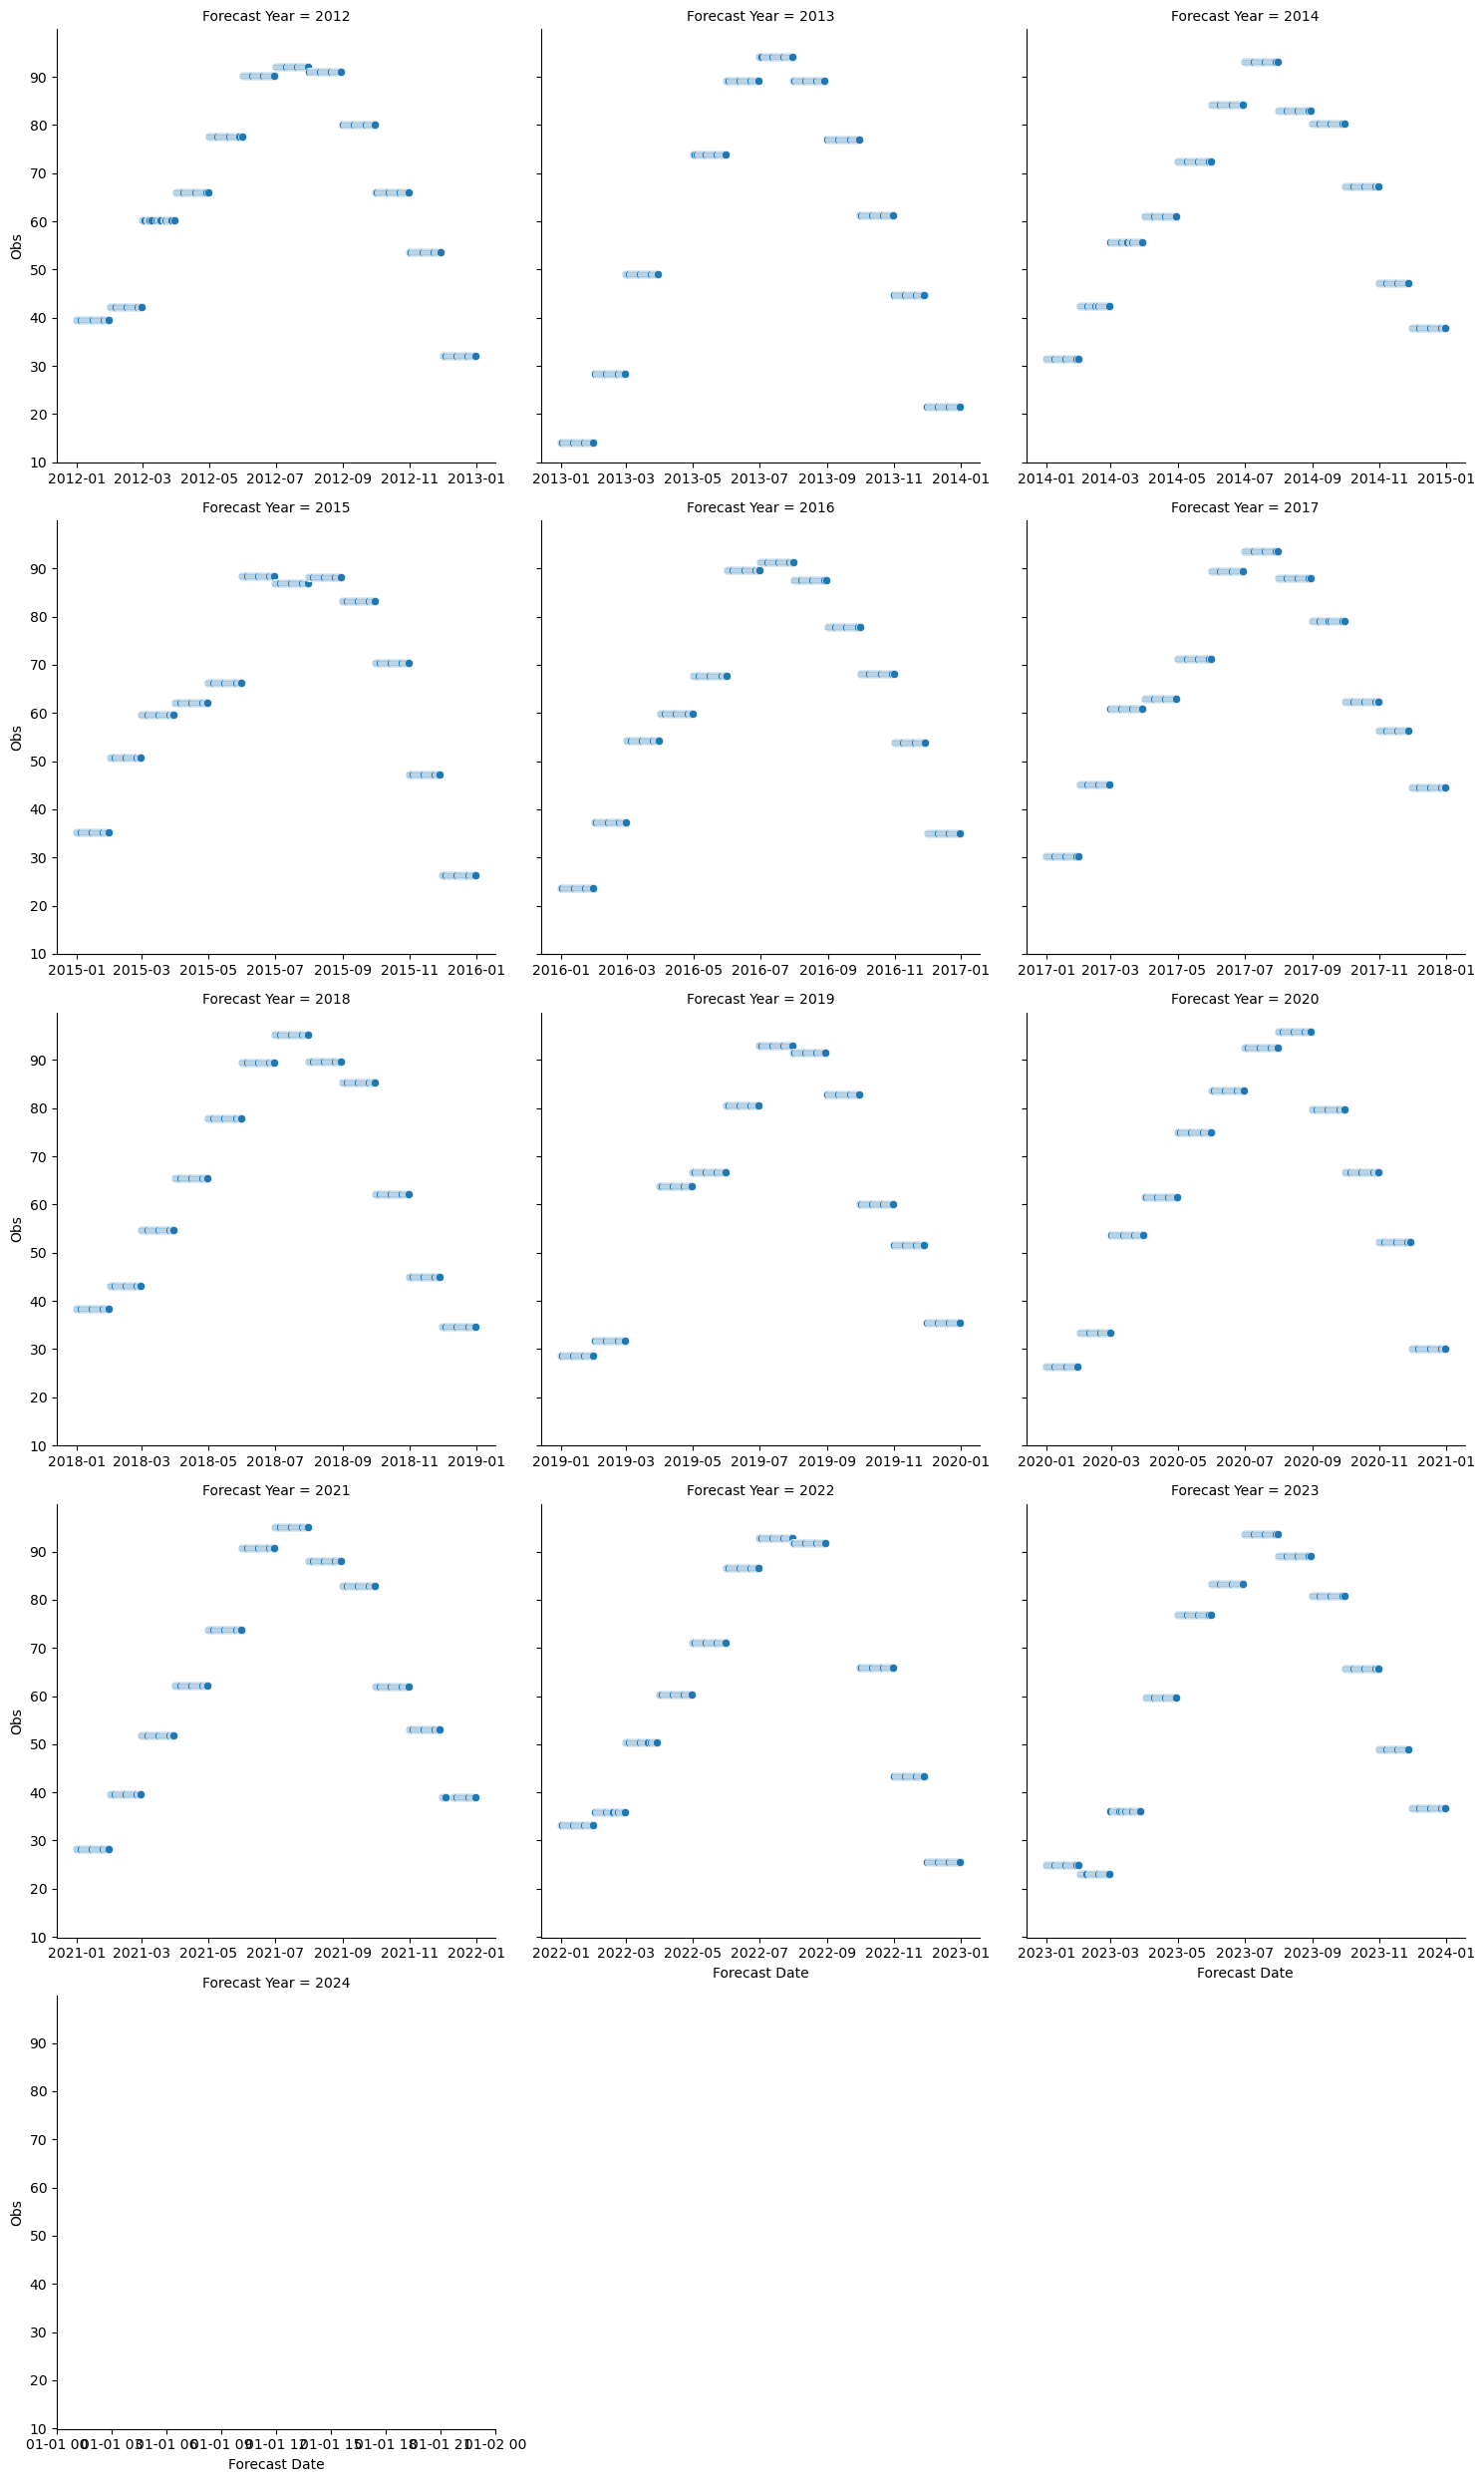

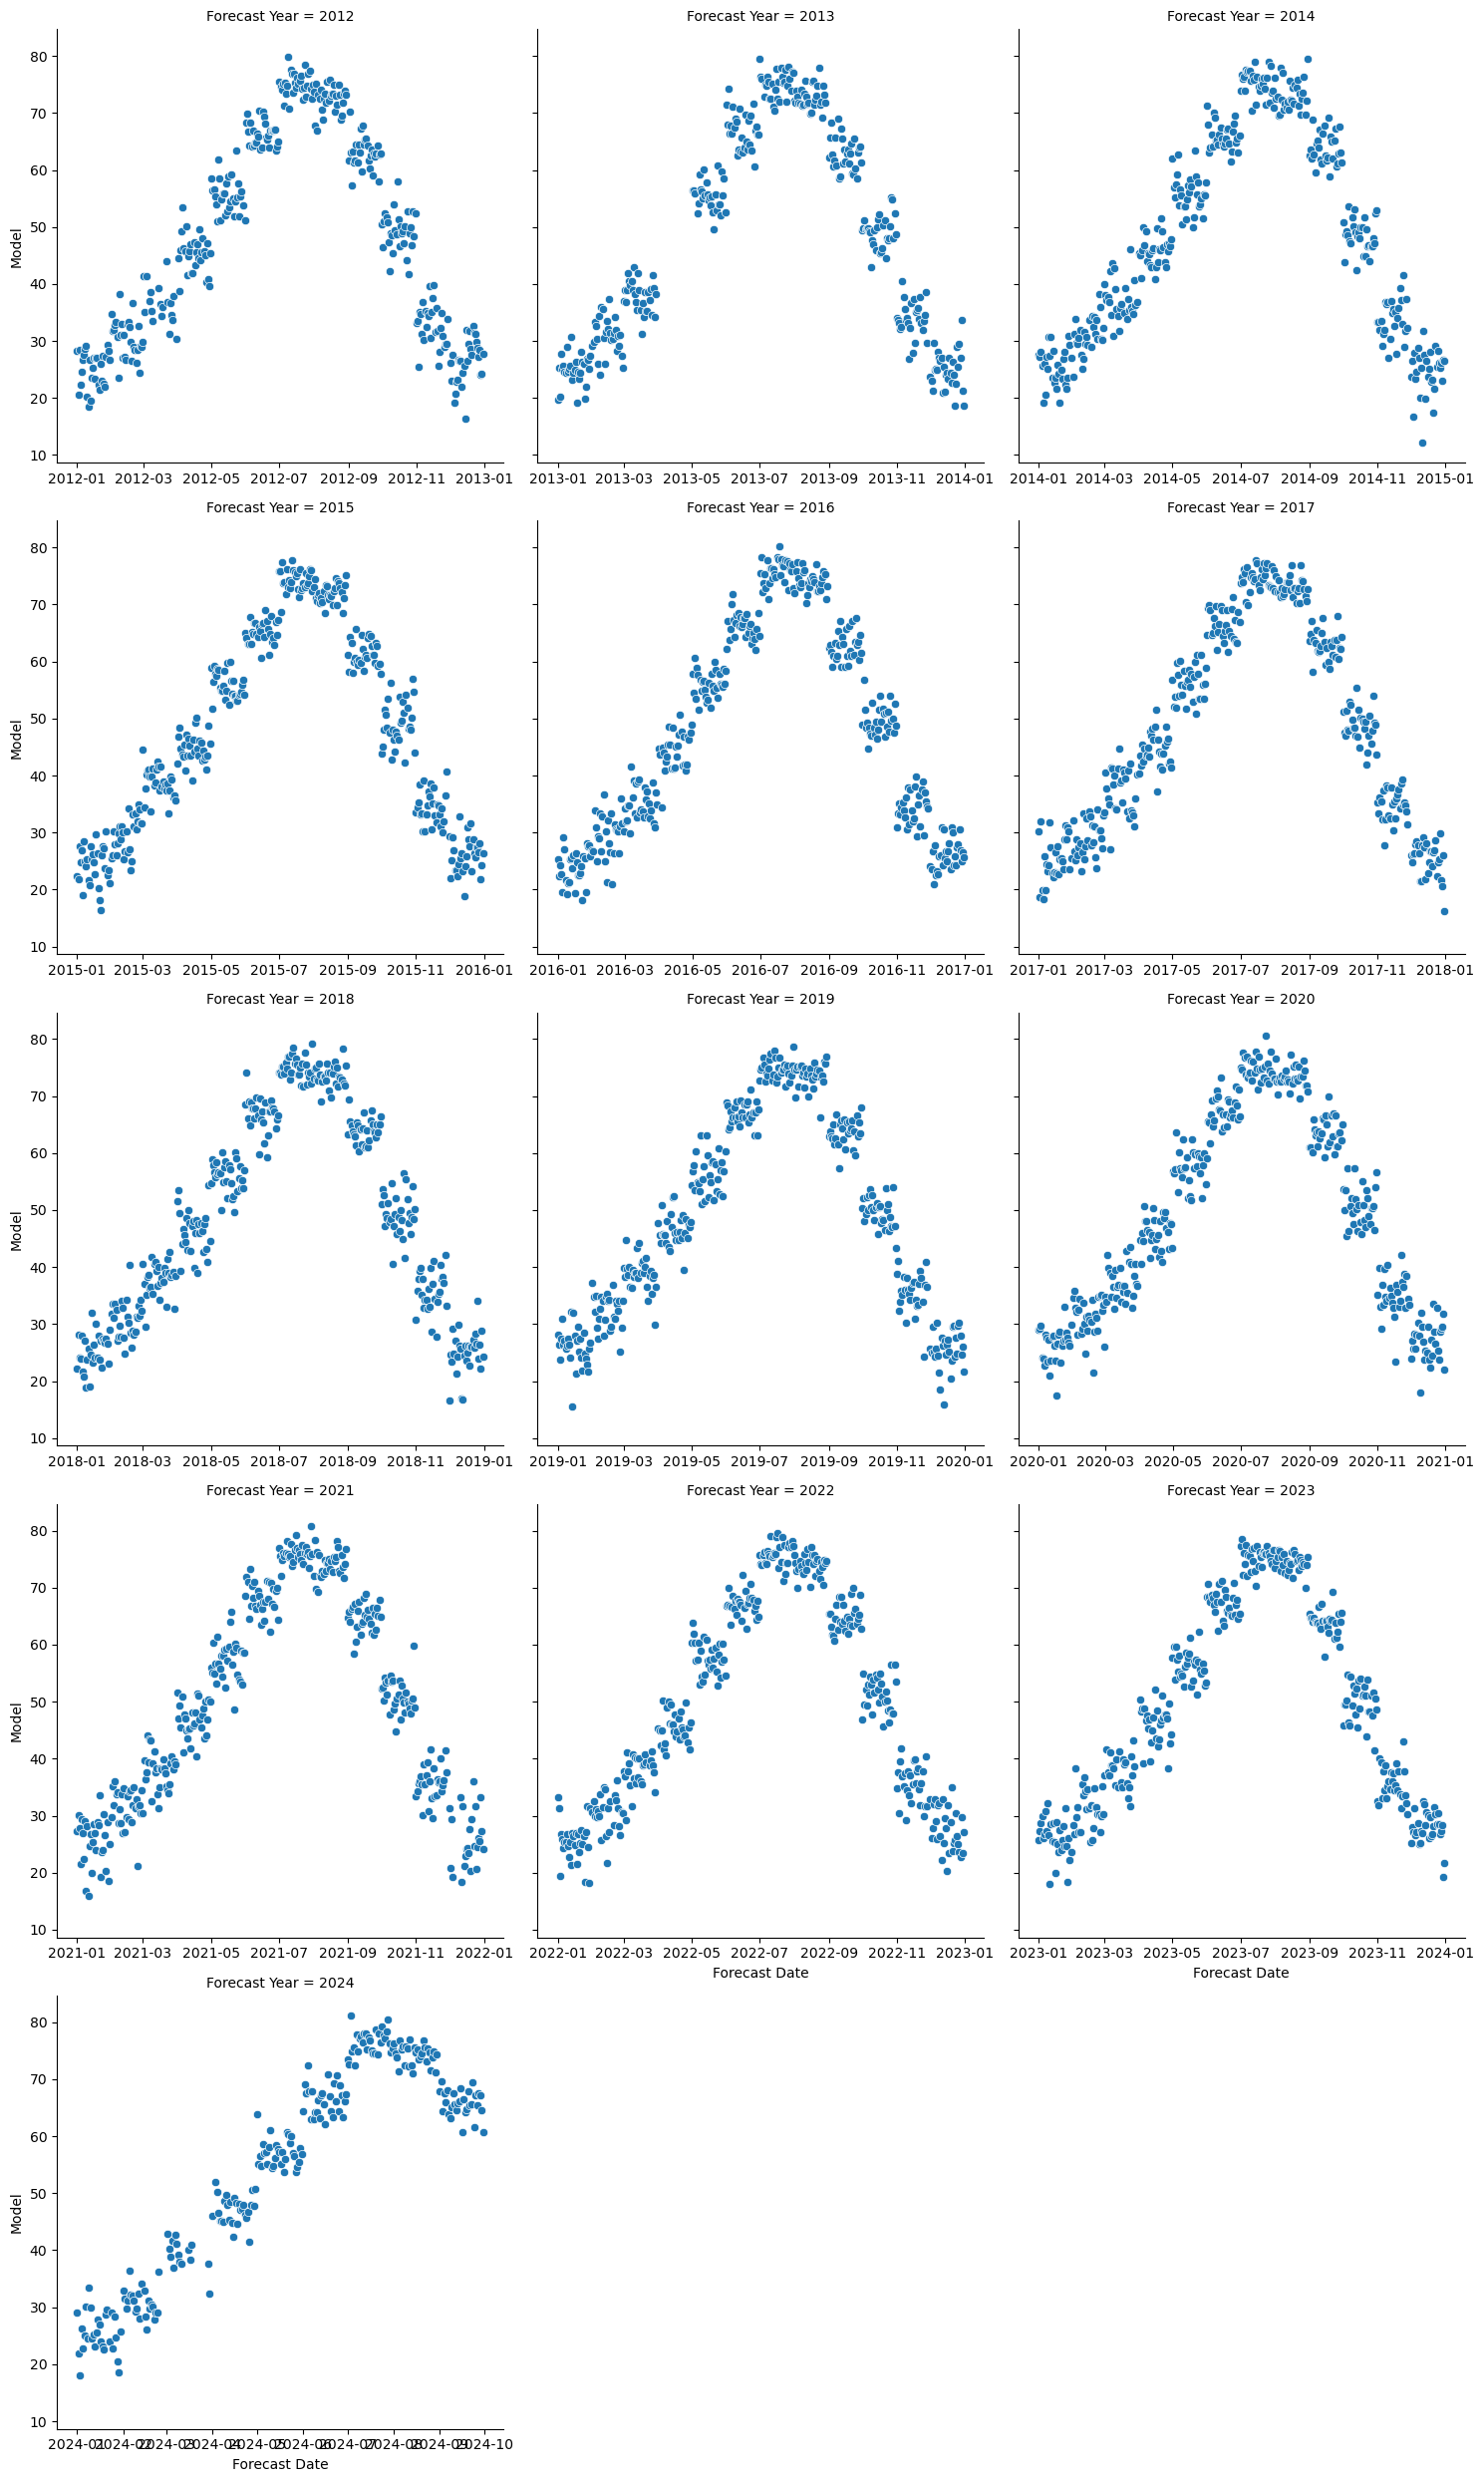

In [86]:
tmp2 = tmp.loc[ (tmp["Forecast Bin"] ==9) ]

sns.relplot(data=tmp2, x="Forecast Date", y="Obs",  col="Forecast Year",col_wrap=3,facet_kws={'sharex':False})
sns.relplot(data=tmp2, x="Forecast Date", y="Model",  col="Forecast Year",col_wrap=3,facet_kws={'sharex':False})


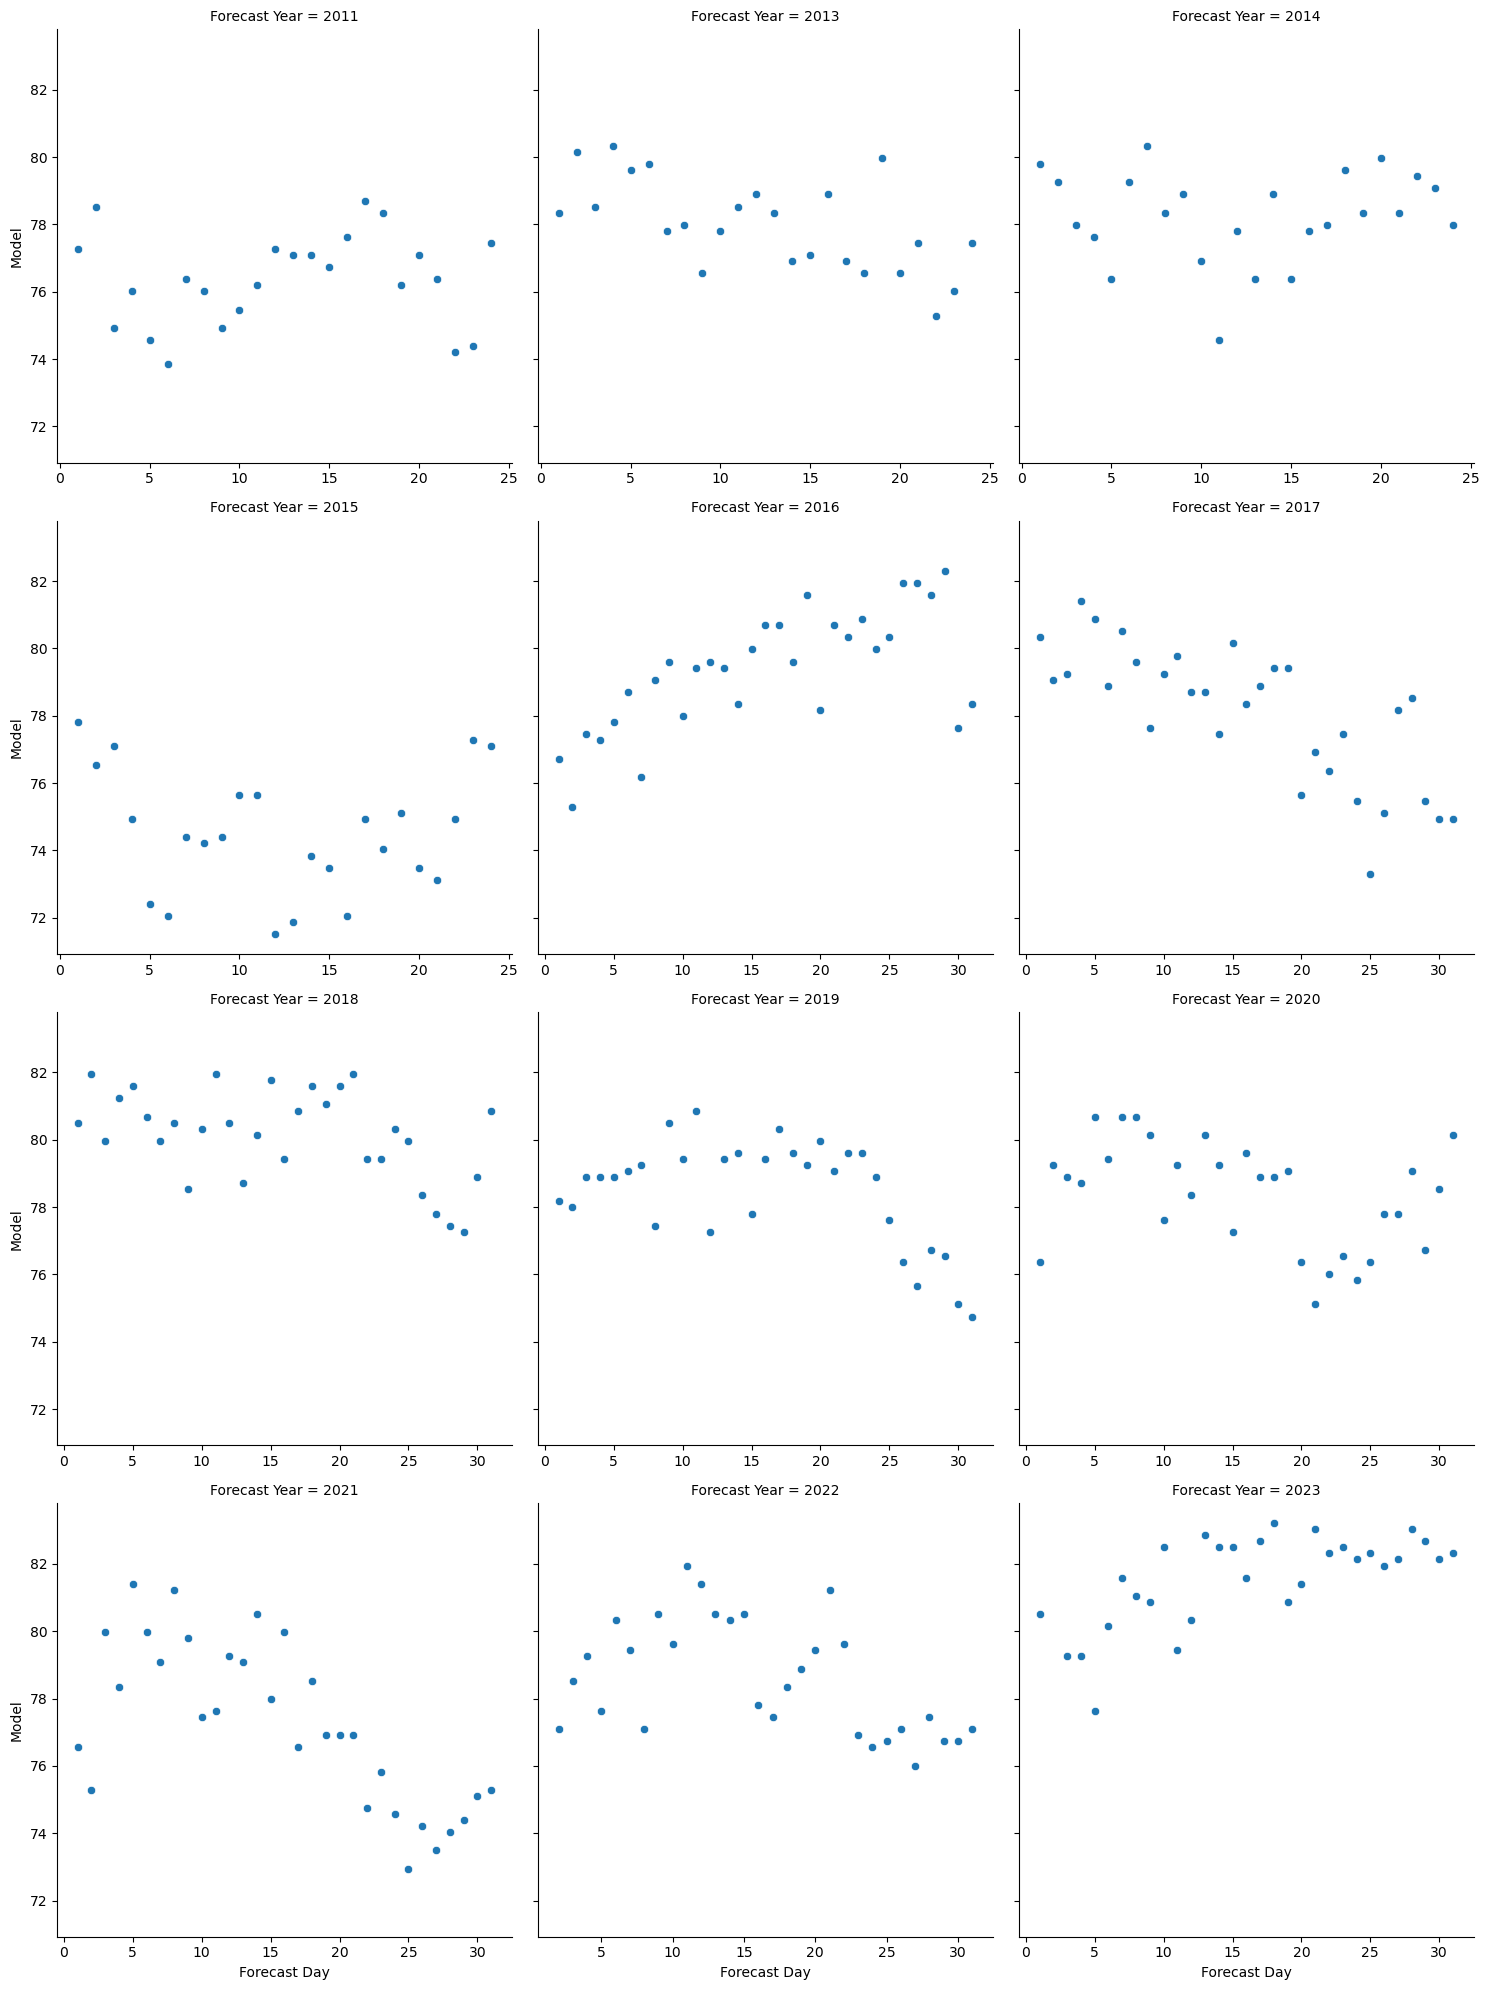

In [91]:
tmp2 = tmp.loc[(tmp["Forecast Month"] == 7) & (tmp["Forecast Bin"] ==0) ]
sns.relplot(data=tmp2, x="Forecast Day", y="Model",  col="Forecast Year",col_wrap=3,facet_kws={'sharex':False})


In [93]:
tmp2.groupby("Forecast Year")[["Model","Obs"]].mean()

,Model,Obs
Forecast Year,,
2011,76.362500,88.4
2013,77.990000,94.2
2014,78.222500,93.1
2015,74.495000,86.9
2016,79.342903,91.3
2017,78.065484,93.6
2018,80.150000,95.2
2019,78.454516,92.9
2020,78.373226,92.6


In [98]:
a=tmp.groupby(["Forecast Bin","Forecast Year"],as_index=False)[["Model","Obs","Diff"]].mean()


In [99]:
a.head(100)

,Forecast Bin,Forecast Year,Model,Obs,Diff
0,0,2011,53.743301,67.038835,13.295534
1,0,2012,49.249538,63.318846,14.069308
2,0,2013,48.443474,58.046316,9.602842
3,0,2014,50.899375,62.983333,12.083958
4,0,2015,51.137500,63.716667,12.579167
...,...,...,...,...,...
95,6,2023,51.172687,61.252239,10.079552
96,6,2024,46.205843,NaN,8.670000
97,7,2011,30.576230,38.868852,8.292623
98,7,2012,49.638718,66.834473,17.195755


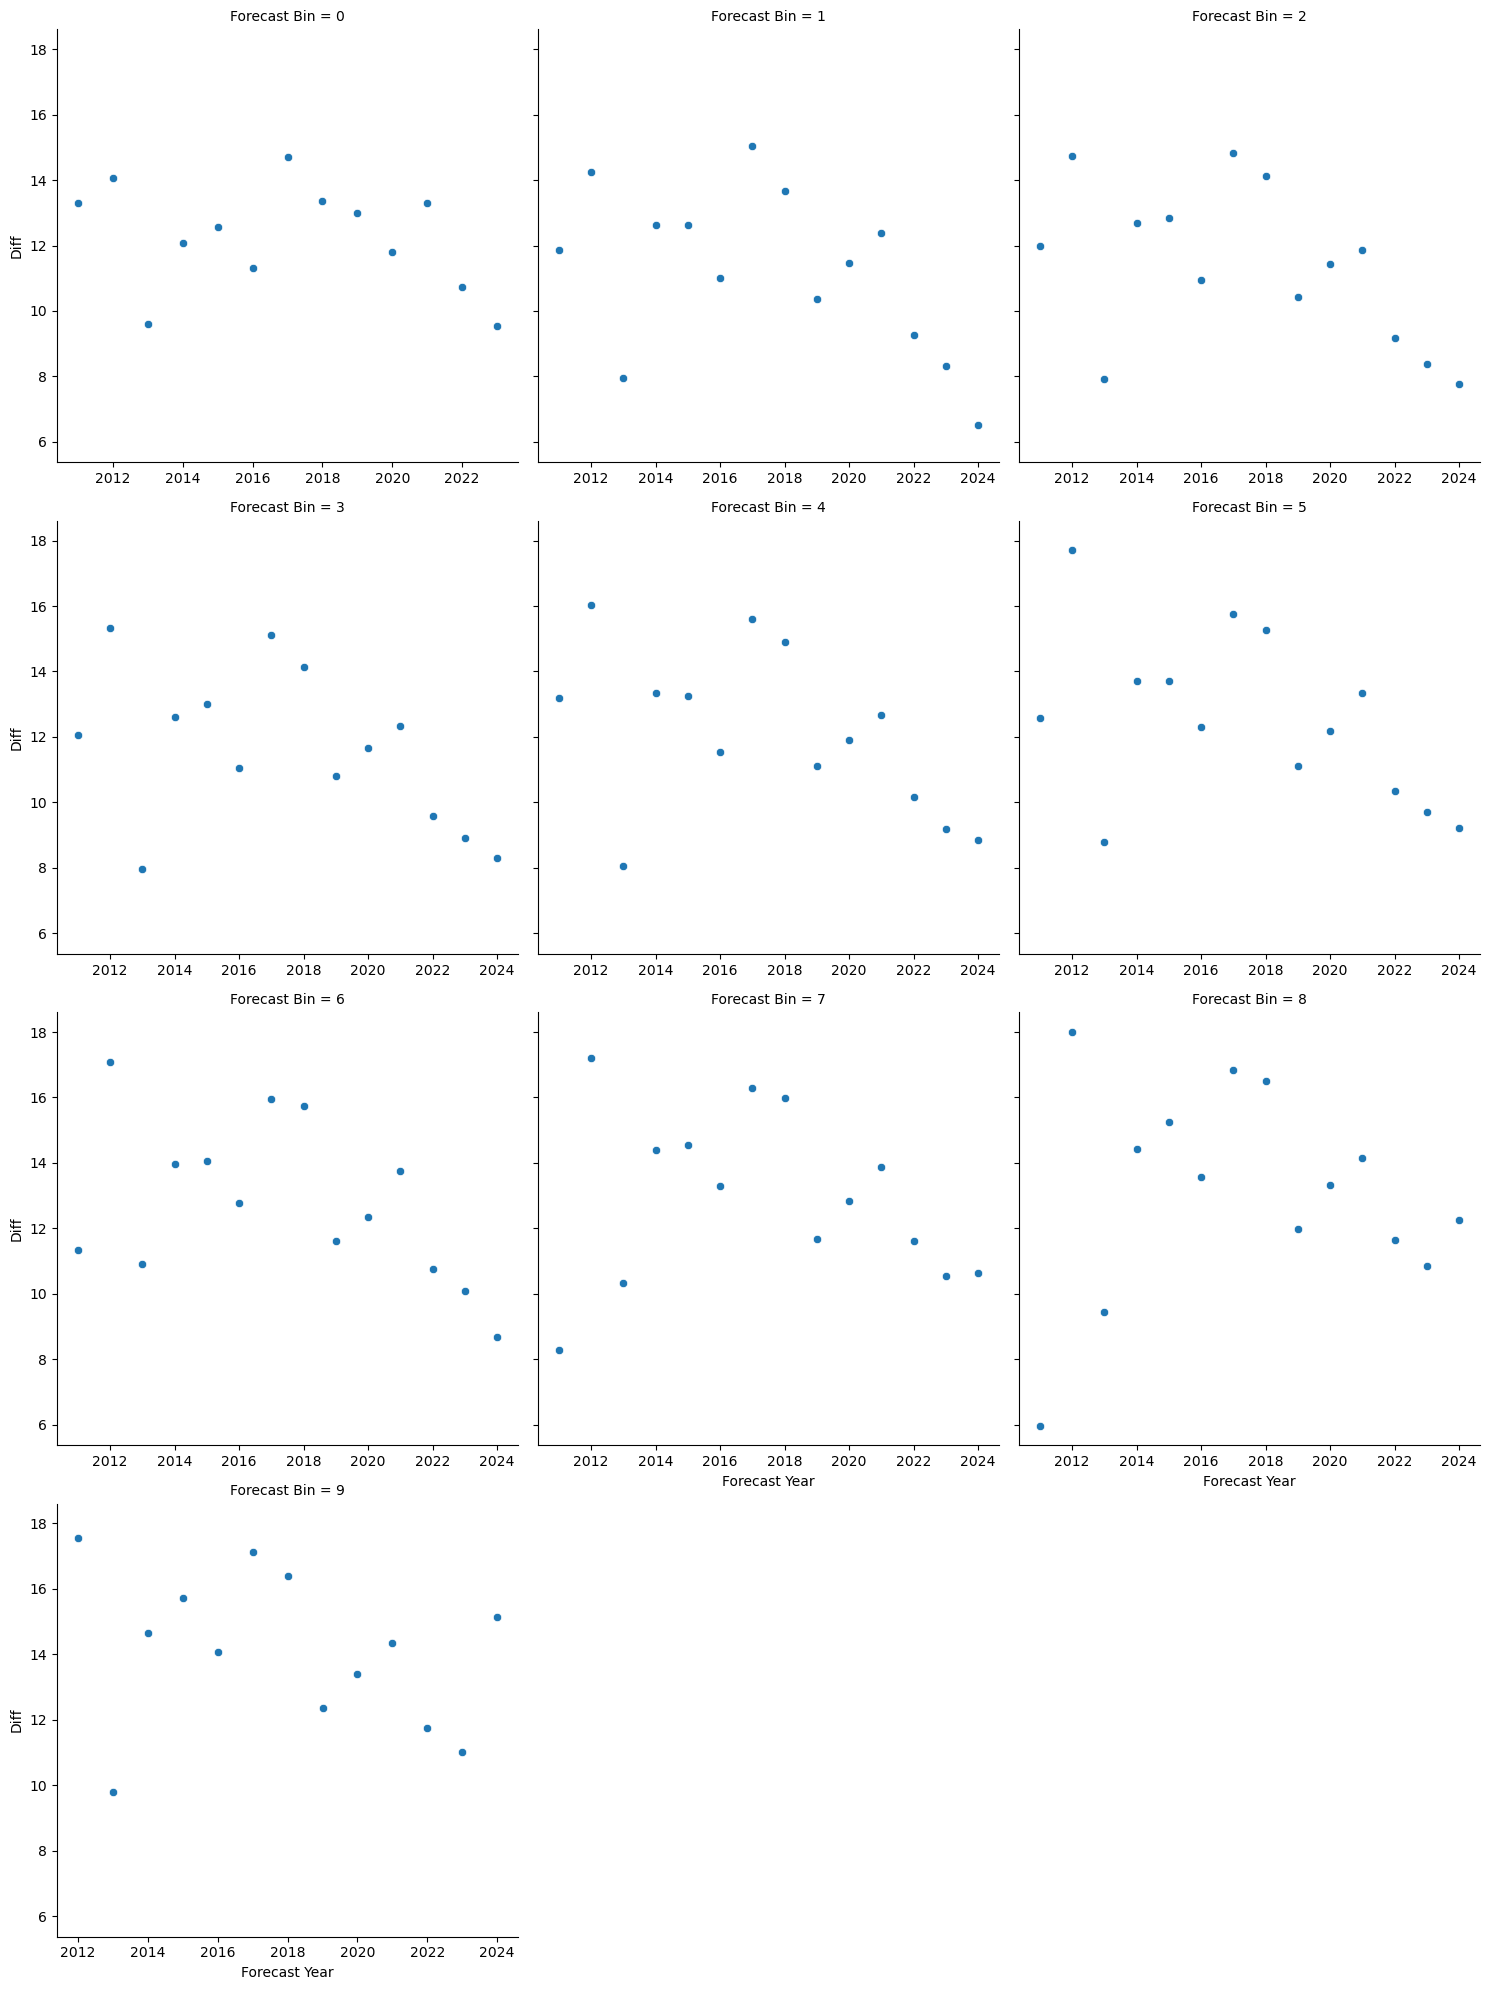

In [100]:
sns.relplot(data=a, x="Forecast Year", y="Diff",  col="Forecast Bin",col_wrap=3,facet_kws={'sharex':False})


In [79]:
tips = sns.load_dataset("tips")

In [80]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='Forecast Year', ylabel='Obs'>

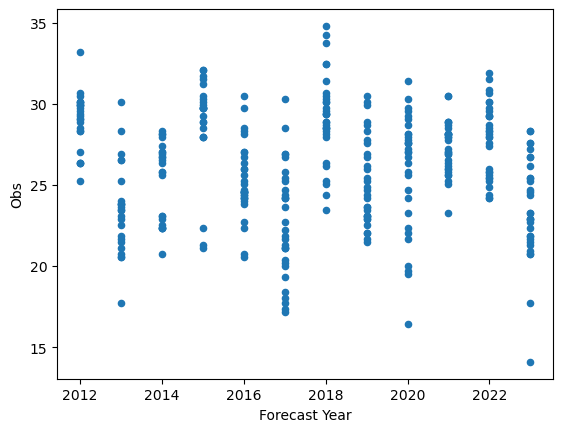

In [48]:
tmp.loc[(tmp["Forecast Month"] == 1) & (tmp["Forecast Bin"] == 0),["Forecast Year","Obs"]].plot.scatter(x="Forecast Year",y="Obs")

In [120]:
a=tmp.groupby(["month","day"])["diffs"].mean()

<Axes: xlabel='month,day'>

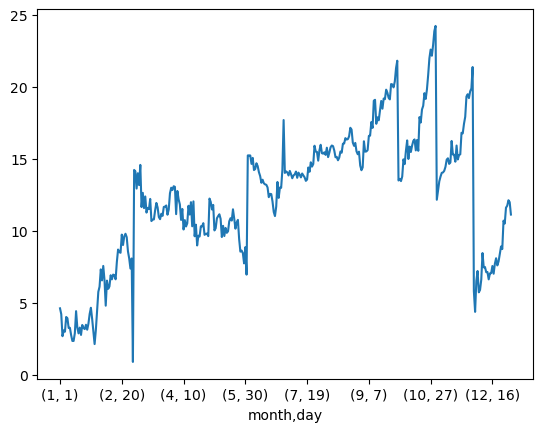

In [125]:
a.plot()

#### ECMWF

In [31]:
df = pd.DataFrame({
"Date":dates,
"Fdate":fdates,
"Fint":fint,
"Year":yrs,
"Month":mos,
"Day":dys,
"Obs":obs
})

#### Read ECMWF Data

In [3]:
def decodeGrib(grb,data,latlons):
    dat=grb.data()
    adate=f"{str(grb.analDate.date().month).zfill(2):2s}/{str(grb.analDate.date().day).zfill(2)}/{str(grb.analDate.date().year).zfill(2)}"
    nfct=grb.forecastTime
    fdate = f"{str(int(grb.monthOfEndOfOverallTimeInterval)).zfill(2):2s}/01/{int(grb.yearOfEndOfOverallTimeInterval):4d}"
    var=grb.shortName
    PT=0
 
    for j in range(0,grb.Nj):
        for i in range(0,grb.Ni):
            PT+=1
            val=dat[0][j][i]
            lat=dat[1][j][i]
            lon=dat[2][j][i]  
            if PT not in data:
                data[PT]={}
            if adate not in data[PT]:
                data[PT][adate]={}
            if fdate not in data[PT][adate]:
                data[PT][adate][fdate]={}
            if nfct not in data[PT][adate][fdate]:
                data[PT][adate][fdate][nfct]={}
                
            if var not in data[PT][adate][fdate][nfct]:
                data[PT][adate][fdate][nfct][var]=val
            
            if PT not in latlons:
                latlons[PT]={}
                latlons[PT]["Lat"]=lat
                latlons[PT]["Lon"]=lon
    return data,latlons


def K2F(K):
       return (K - 273.15) * 9/5 + 32


def tTd2RH(t,td):
#  t,td should be in C
    rh=  100 * (math.exp((17.625 * td) / (243.04 + td))) / (math.exp((17.625 * t) / (243.04 + t)))
    return rh

def vpd(T,RH):
#    T should in in C
 #   tt=T-273.15
    tt=T
    es =0.6108*math.exp((17.27*tt)/(tt+237.3))
    if RH>1:
       val=100
    else:
        val=1
    ea=RH/val*es
    return es-ea
# Iterate over the messages in the file

grbs = pygrib.open("ecmwf_51.grib")

latlons={}
data={}
for grb in grbs:
    data,latlons=decodeGrib(grb,data,latlons)

fout=open("Data/ecmwfTTdRhVpd.csv","w")
fout.write("point,analysisDate,forecastDate,forecastInterval,t,td,rh,vpd\n")
for pt,dct in data.items():
    for adate,dct1 in dct.items():
        for fdate,dct2 in dct1.items():
            for nfcts,dct3 in dct2.items():
                Td = dct3['2d']-273.15
                T = dct3['2t']-273.15
                RH=tTd2RH(T,Td)
                VPD=vpd(T,RH)
                data[pt][adate][fdate][nfcts]['rh']=RH
                data[pt][adate][fdate][nfcts]['vpd']=VPD
                fout.write(f"{pt},{adate},{fdate},{nfcts},{T:.1f},{Td:.1f},{RH:.1f},{VPD:.3f}\n")
                
fout.close()               


In [9]:
fout=open("Data/ecmwf_51_latlons.csv","w")
fout.write("Point,Lat,Lon\n")
for pt,dct in latlons.items():
    fout.write(f"{pt},{dct['Lat']},{dct['Lon']}\n")
fout.close()

In [75]:
df=pd.read_csv("Data/ecmwfTTdRhVpd.csv")

<Axes: xlabel='forecastDate'>

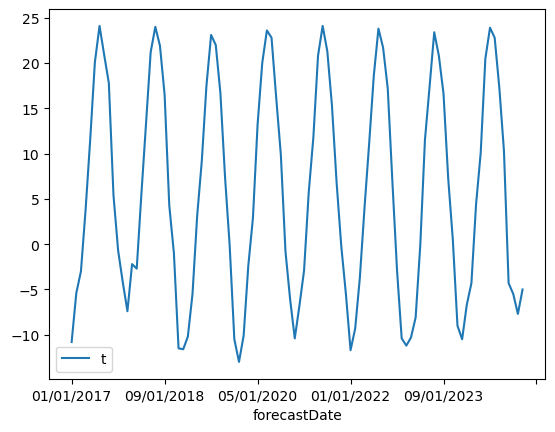

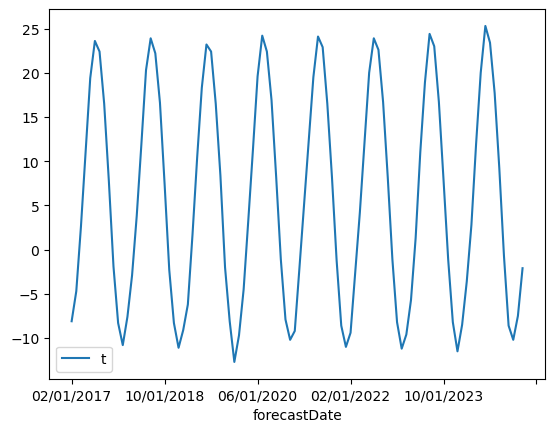

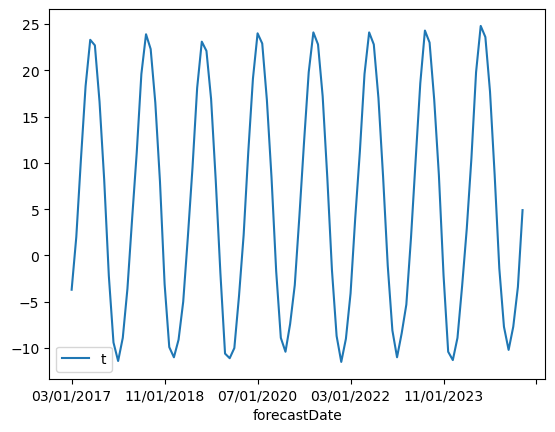

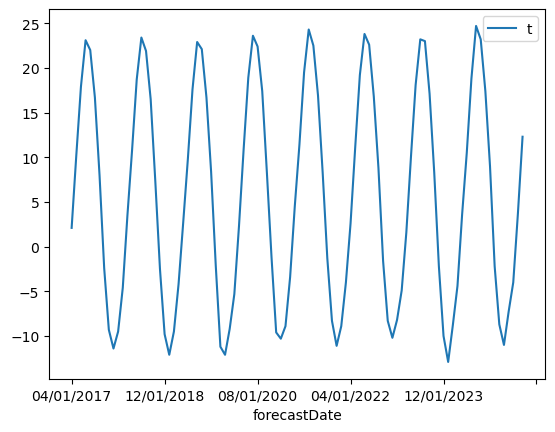

In [79]:
df.loc[(df["point"] == 1) & (df["forecastInterval"] == 0)].plot(x="forecastDate",y="t")
df.loc[(df["point"] == 1) & (df["forecastInterval"] == 1)].plot(x="forecastDate",y="t")
df.loc[(df["point"] == 1) & (df["forecastInterval"] == 2)].plot(x="forecastDate",y="t")
df.loc[(df["point"] == 1) & (df["forecastInterval"] == 3)].plot(x="forecastDate",y="t")


In [71]:
data[1]['01/01/2017']['01/01/2017']

{0: {'2d': 259.428466796875,
  '2t': 262.37158203125,
  'rh': 78.92282438715417,
  'vpd': 0.056601969958194776}}

In [29]:
grb.data()

(array([[296.92675781, 295.26269531, 293.27709961, 292.07714844,
         294.66625977, 298.66137695, 299.23974609, 299.6003418 ],
        [297.21069336, 295.50048828, 290.59399414, 289.37866211,
         294.10009766, 298.16015625, 299.60864258, 299.98144531],
        [298.60131836, 293.89892578, 288.9296875 , 289.37866211,
         294.16772461, 298.53051758, 300.00170898, 300.73291016],
        [297.53759766, 292.76147461, 289.74389648, 290.20874023,
         293.78491211, 298.20581055, 300.83544922, 301.58227539],
        [297.33032227, 296.18164062, 293.12329102, 290.19042969,
         293.79199219, 297.27880859, 299.94946289, 302.17700195]]),
 array([[41., 41., 41., 41., 41., 41., 41., 41.],
        [40., 40., 40., 40., 40., 40., 40., 40.],
        [39., 39., 39., 39., 39., 39., 39., 39.],
        [38., 38., 38., 38., 38., 38., 38., 38.],
        [37., 37., 37., 37., 37., 37., 37., 37.]]),
 array([[-109., -108., -107., -106., -105., -104., -103., -102.],
        [-109., -108., -1

In [56]:
def decodeGrib(grb,data,latlons):
    dat=grb.data()
    adate=f"{str(grb.analDate.date().month).zfill(2):2s}/{str(grb.analDate.date().day).zfill(2)}/{str(grb.analDate.date().year).zfill(2)}"
    nfct=grb.forecastTime
    fdate = f"{str(int(grb.monthOfEndOfOverallTimeInterval)).zfill(2):2s}/01/{int(grb.yearOfEndOfOverallTimeInterval):4d}"
    var=grb.shortName
    PT=0
 
    for j in range(0,grb.Nj):
        for i in range(0,grb.Ni):
            PT+=1
            val=dat[0][j][i]
            lat=dat[1][j][i]
            lon=dat[2][j][i]  
            if PT not in data:
                data[PT]={}
            if adate not in data[PT]:
                data[PT][adate]={}
            if fdate not in data[PT][adate]:
                data[PT][adate][fdate]={}
            if nfct not in data[PT][adate][fdate]:
                data[PT][adate][fdate][nfct]={}
                
            if var not in data[PT][adate][fdate][nfct]:
                data[PT][adate][fdate][nfct][var]=val
            
            if PT not in latlons:
                latlons[PT]={}
                latlons[PT]["Lat"]=lat
                latlons[PT]["Lon"]=lon
    return data,latlons
     
        

In [53]:
latlons

{1: {'Lat': 41.0, 'Lon': -109.0},
 2: {'Lat': 41.0, 'Lon': -108.0},
 3: {'Lat': 41.0, 'Lon': -107.0},
 4: {'Lat': 41.0, 'Lon': -106.0},
 5: {'Lat': 41.0, 'Lon': -105.0},
 6: {'Lat': 41.0, 'Lon': -104.0},
 7: {'Lat': 41.0, 'Lon': -103.0},
 8: {'Lat': 41.0, 'Lon': -102.0},
 9: {'Lat': 40.0, 'Lon': -109.0},
 10: {'Lat': 40.0, 'Lon': -108.0},
 11: {'Lat': 40.0, 'Lon': -107.0},
 12: {'Lat': 40.0, 'Lon': -106.0},
 13: {'Lat': 40.0, 'Lon': -105.0},
 14: {'Lat': 40.0, 'Lon': -104.0},
 15: {'Lat': 40.0, 'Lon': -103.0},
 16: {'Lat': 40.0, 'Lon': -102.0},
 17: {'Lat': 39.0, 'Lon': -109.0},
 18: {'Lat': 39.0, 'Lon': -108.0},
 19: {'Lat': 39.0, 'Lon': -107.0},
 20: {'Lat': 39.0, 'Lon': -106.0},
 21: {'Lat': 39.0, 'Lon': -105.0},
 22: {'Lat': 39.0, 'Lon': -104.0},
 23: {'Lat': 39.0, 'Lon': -103.0},
 24: {'Lat': 39.0, 'Lon': -102.0},
 25: {'Lat': 38.0, 'Lon': -109.0},
 26: {'Lat': 38.0, 'Lon': -108.0},
 27: {'Lat': 38.0, 'Lon': -107.0},
 28: {'Lat': 38.0, 'Lon': -106.0},
 29: {'Lat': 38.0, 'Lon': -10

In [54]:
data

{1: {'02/01/2025': {'07/01/2025': {5: {'2t': 296.9267578125}}}},
 2: {'02/01/2025': {'07/01/2025': {5: {'2t': 295.2626953125}}}},
 3: {'02/01/2025': {'07/01/2025': {5: {'2t': 293.277099609375}}}},
 4: {'02/01/2025': {'07/01/2025': {5: {'2t': 292.0771484375}}}},
 5: {'02/01/2025': {'07/01/2025': {5: {'2t': 294.666259765625}}}},
 6: {'02/01/2025': {'07/01/2025': {5: {'2t': 298.661376953125}}}},
 7: {'02/01/2025': {'07/01/2025': {5: {'2t': 299.23974609375}}}},
 8: {'02/01/2025': {'07/01/2025': {5: {'2t': 299.600341796875}}}},
 9: {'02/01/2025': {'07/01/2025': {5: {'2t': 297.210693359375}}}},
 10: {'02/01/2025': {'07/01/2025': {5: {'2t': 295.50048828125}}}},
 11: {'02/01/2025': {'07/01/2025': {5: {'2t': 290.593994140625}}}},
 12: {'02/01/2025': {'07/01/2025': {5: {'2t': 289.378662109375}}}},
 13: {'02/01/2025': {'07/01/2025': {5: {'2t': 294.10009765625}}}},
 14: {'02/01/2025': {'07/01/2025': {5: {'2t': 298.16015625}}}},
 15: {'02/01/2025': {'07/01/2025': {5: {'2t': 299.608642578125}}}},
 1

In [43]:
nfct

5

In [18]:
grb.analDate,grb.forecastTime,grb.shortName,grb.fcstimeunits,grb.yearOfEndOfOverallTimeInterval,grb.monthOfEndOfOverallTimeInterval

(datetime.datetime(2024, 10, 1, 0, 0), 5, 'mn2t24', 'hrs', 2025.0, 3.0)

In [32]:
grb.forecastTime

5

'02/01/2025'

In [9]:
grb.shortName

'mn2t24'

##### Match ECMWF Points to CFSV2

In [22]:
xrefsEcmwf={}
grb=grbs[1]
for index,row in latlons.iterrows():
    lat=row['Lat']
    lon=row['Lon']
    latE=grb.latLonValues[0]
    lonE=grb.latLonValues[1]
    distMin = haversine(lat,lon,latE,lonE)
    nnMin=0
    pt=f"f{index+1}"
    for nn,row in enumerate(grb.latLonValues.reshape(-1,3)):
        latE=row[0]
        lonE=row[1]
        if lonE < 0:
            lonE=360+lonE
        dist = haversine(lat,lon,latE,lonE)
        if dist < distMin:
            distMin=dist
            latMin=latE
            lonMin=lonE
            nnMin=nn
 #   print(index,lat,lon,distMin,nnMin,latMin,lonMin,grb.latLonValues.reshape(-1,3)[nnMin])
    xrefsEcmwf[f"p{index+1}"] = {}
    xrefsEcmwf[f"p{index+1}"]["index"] = nnMin
    xrefsEcmwf[f"p{index+1}"]["lat"] = latMin
    xrefsEcmwf[f"p{index+1}"]["lon"] = lonMin
    xrefsEcmwf[f"p{index+1}"]["latC"] = lat
    xrefsEcmwf[f"p{index+1}"]["lonC"] = lon
    xrefsEcmwf[f"p{index+1}"]["dist"] = distMin
    
    
    

##### Match ECMWF to GSOD Stations

In [23]:
    for station,dct in histBest.items():
        nrec+=1
        latd = dct["lat"]
        lond = dct["lon"]
        
        dist = haversine(lat,lon,latd,lond)
        
        if nrec==1:
            distMin=dist
            stationMin=station
        if dist < distMin:
            distMin=dist
            stationMin=station

In [24]:
xrefsEcmwf

{'p1': {'index': 21,
  'lat': 40.0,
  'lon': 251.0,
  'latC': 40.15731379530128,
  'lonC': 251.2496501305483,
  'dist': 27.516458922316726},
 'p2': {'index': 22,
  'lat': 40.0,
  'lon': 252.0,
  'latC': 40.15731379530128,
  'lonC': 252.1871488250653,
  'dist': 23.654364355906342},
 'p3': {'index': 23,
  'lat': 40.0,
  'lon': 253.0,
  'latC': 40.15731379530128,
  'lonC': 253.12464751958225,
  'dist': 20.45626703445805},
 'p4': {'index': 24,
  'lat': 40.0,
  'lon': 254.0,
  'latC': 40.15731379530128,
  'lonC': 254.0621462140992,
  'dist': 18.274170430398527},
 'p5': {'index': 25,
  'lat': 40.0,
  'lon': 255.0,
  'latC': 40.15731379530128,
  'lonC': 254.9996449086162,
  'dist': 17.492522018652675},
 'p6': {'index': 26,
  'lat': 40.0,
  'lon': 256.0,
  'latC': 40.15731379530128,
  'lonC': 255.9371436031332,
  'dist': 18.291745125511138},
 'p7': {'index': 27,
  'lat': 40.0,
  'lon': 257.0,
  'latC': 40.15731379530128,
  'lonC': 256.8746422976501,
  'dist': 20.487657999461018},
 'p8': {'inde

In [ ]:
vrs = ["p1","p2","p3","p4","p5","p6","p7","p8","p9","p10","p11","p12","p13","p14","p15","p16","p17","p18","p19","p20","p21","p22","p23","p24","p25","p26","p27","p28","p29","p30","p31","p32"]

gathered={}
for pt in vrs:
    gathered[pt]={}
    stn = list(compares[pt].keys())[0]
    eindex = xrefsEcmwf[pt]['index']
    print(pt,eindex)
    for tbin in range(0,10):
        gathered[pt][tbin]={}
        for date,dct in sorted(compares[pt]["modelf"][tbin].items()):
            gathered[pt][tbin][date]={}
            gathered[pt][tbin][date]["analDate"]=dct["analdate"]
            gathered[pt][tbin][date]["cfs"]=K2F(dct["value"])
            gathered[pt][tbin][date]["cfso"]=dct["value"]
        #    print(gathered[pt][tbin][date]["cfs"],gathered[pt][tbin][date]["cfso"])
            fyrmo = date[:7]
            if fyrmo in compares[pt][stn]: 
                gathered[pt][tbin][date]["obs"] = compares[pt][stn][fyrmo]
            if tbin in ecmwf and fyrmo in ecmwf[tbin]:
                gathered[pt][tbin][date]['ecm']=ecmwf[tbin][fyrmo][eindex]
        

##### Analysis

In [27]:
stats={}

for pt in vrs:
    fbin=0
    stats[pt]={}
    print(pt)
    for fbin in range(0,6):
        stats[pt][fbin]={}
        for yr in range(2017,2024):
            stats[pt][fbin][yr]={}
            
            for mo in range(1,13):
                
                stats[pt][fbin][yr][mo]={}
                    
                mos=str(mo).zfill(2)
                
                tt=[]
                tmp={0:[],1:[],2:[],3:[]}
                for dy in range(1,28):
                    mbin= int(dy/10)
                    
                    dy=str(dy).zfill(2)
                    date=f"{yr}-{mos}-{dy}"
                    if date in gathered[pt][fbin] and 'obs' in gathered[pt][fbin][date] and 'cfs' in gathered[pt][fbin][date] and 'ecm' in gathered[pt][fbin][date]: 
                        tt.append(gathered[pt][fbin][date]['cfs'])
                        obs=gathered[pt][fbin][date]['obs']
                        ecm=gathered[pt][fbin][date]['ecm']                 
                        tmp[mbin].append(gathered[pt][fbin][date]['cfs'])
                if len(tt) > 4:
                    for mbin in tmp:
                        if len(tmp[mbin]) > 0:
                           mn = stat.mean(tmp[mbin])
                         
                        else:
                           mn=-99
                        tmp[mbin]=mn
               #     print(yr,mo,len(tt),obs,stats.median(tt),stats.mean(tt),tmp[0],tmp[1],tmp[2])
                    edf = obs-ecm
                    cdfmn = obs-stat.mean(tt)
                    cdfmd = obs-stat.median(tt)  
                #    print(f"{yr} {mo}  {len(tt)} {obs} {edf:.2f}  {(cdfmd):.1f} {(cdfmn):.2f}  {(obs-tmp[0]):.2f} {(obs-tmp[1]):.2f}  {(obs-tmp[2]):.2f}")
                    stats[pt][fbin][yr][mo]['obs']=obs
                    stats[pt][fbin][yr][mo]['cfs']=stat.mean(tt)
                    stats[pt][fbin][yr][mo]['cfsmd']=stat.median(tt)
                  
                    stats[pt][fbin][yr][mo]['cfs0']=tmp[0]
                  
                    stats[pt][fbin][yr][mo]['cfs1']=tmp[1]
                   
                    stats[pt][fbin][yr][mo]['cfs2']=tmp[2]
                    stats[pt][fbin][yr][mo]['ecm']=ecm
                
                
                
                
                

p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19
p20
p21
p22
p23
p24
p25
p26
p27
p28
p29
p30
p31
p32


In [28]:
points=[]
fbins=[]
years=[]
months= [] 
obs=[] 
cfs=[]
cfsmd=[]
cfs0=[]
cfs1=[]
cfs2=[]
ecm=[]

for pt,dct in stats.items():
    for fbin,dct2 in dct.items():
        for yr,dct3 in dct2.items():
            for mo in range(1,13):
        #    for mo,dct4 in dct3.items():
               if mo in dct3 and len(dct3[mo].keys()) > 0:
                    dct4=dct3[mo]
                    points.append(pt)
                    fbins.append(fbin)
                    years.append(yr)
                    months.append(mo)
                    obs.append(dct4['obs'])
                    cfs.append(dct4['cfs'])
                    cfsmd.append(dct4['cfsmd'])
                    cfs0.append(dct4['cfs0'])
                    cfs1.append(dct4['cfs1'])
                    cfs2.append(dct4['cfs2'])
                    ecm.append(dct4['ecm'])
               else:
                    points.append(pt)
                    fbins.append(fbin)
                    years.append(yr)
                    months.append(mo)
                    obs.append(np.nan)
                    cfs.append(np.nan)
                    cfsmd.append(np.nan)
                    cfs0.append(np.nan)
                    cfs1.append(np.nan)
                    cfs2.append(np.nan)
                    ecm.append(np.nan)
                

In [29]:
df = pd.DataFrame({
"Point":points,
"Fbin":fbins,
"Year":years,
"Month":months,
"Obs":obs,
"Cfs":cfs,
"Ecm":ecm,
"Cfsmd":cfsmd,
"Cfs0":cfs0,
"Cfs1":cfs1,
"Cfs2":cfs2
})

In [30]:
df["CfsDiff"] = abs(df["Obs"]-df["Cfs"])
df["EcmDiff"] = abs(df["Obs"]-df["Ecm"])


In [31]:
df.head()

,Point,Fbin,Year,Month,Obs,Cfs,Ecm,Cfsmd,Cfs0,Cfs1,Cfs2,CfsDiff,EcmDiff
0,p1,0,2017,1,30.2,22.343333,26.131367,21.65,24.71,22.784,19.1300,7.856667,4.068633
1,p1,0,2017,2,45.1,32.570000,35.189375,34.25,35.21,35.402,26.0600,12.530000,9.910625
2,p1,0,2017,3,60.9,43.690000,42.633711,44.87,39.91,45.932,45.1400,17.210000,18.266289
3,p1,0,2017,4,63.0,50.016667,53.750557,51.89,51.25,52.610,45.3875,12.983333,9.249443
4,p1,0,2017,5,71.3,59.623333,68.327656,59.81,60.41,59.144,59.3375,11.676667,2.972344


##### ECMWF vs CFSV2 Results

In [34]:
#a=df.groupby(["Point","Fbin"],as_index=False).mean()
modeldiffs = df[["Fbin","Obs","CfsDiff","EcmDiff"]].groupby(["Fbin"],as_index=False).mean()


In [101]:
a.sort_values(by="EcmDiff")

,Point,Fbin,Year,Month,Obs,Cfs,Ecm,Cfsmd,Cfs0,Cfs1,Cfs2,CfsDiff,EcmDiff
60,p19,0,2020.0,6.5,52.898810,41.907523,52.659201,41.980357,42.301696,42.054012,39.391701,10.991286,1.938562
156,p4,0,2020.0,6.5,51.164198,43.244118,49.672654,43.343253,43.792349,43.464747,40.432457,8.015040,2.454146
63,p19,3,2020.0,6.5,53.464198,41.405647,52.625996,41.390000,41.339321,41.431907,39.576698,12.058550,2.473127
61,p19,1,2020.0,6.5,53.200000,41.899429,52.684067,41.871807,41.875422,41.787614,40.114630,11.300571,2.511828
62,p19,2,2020.0,6.5,53.380488,41.893890,52.712445,41.816585,41.884177,41.734738,40.162199,11.486598,2.582768
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,p21,5,2020.0,6.5,69.807692,50.297085,59.794378,50.339494,50.221772,50.169405,48.804534,19.265047,9.684068
7,p10,1,2020.0,6.5,46.033766,46.422033,54.815001,46.476329,46.526709,46.366032,44.242920,2.901879,9.688763
115,p27,1,2020.0,6.5,48.379012,45.182048,57.921994,45.168193,45.162590,45.089867,43.329032,3.971523,9.770863
6,p10,0,2020.0,6.5,45.761538,45.606744,54.791473,45.720500,46.201813,45.836406,42.606866,2.810297,9.824607


In [79]:
df.groupby(["Point","Fbin","Month"]).mean()


Year        Obs        Cfs        Ecm      Cfsmd  \
Point Fbin Month                                                       
p1    0    1      2020.0  29.985714  25.979524  25.302182  26.072857   
           2      2020.0  35.957143  29.128095  32.178054  29.364286   
           3      2020.0  51.233333  39.927933  39.596211  39.804286   
           4      2020.0  62.285714  50.821429  54.056353  50.514286   
           5      2020.0  73.228571  61.661233  69.192437  61.880000   
...                  ...        ...        ...        ...        ...   
      5    8      2020.0  90.542857  74.792857  85.361236  74.981429   
           9      2020.0  81.783333  65.094762  75.962903  65.004286   
           10     2020.0  63.528571  51.516367  60.523785  51.517143   
           11     2020.0  50.042857  36.261625  40.853298  35.792857   
           12     2020.0  35.171429  26.904066  26.615519  27.320000   

                       Cfs0       Cfs1       Cfs2    CfsDiff    EcmDiff  
Point Fbin Month                                                         
p1    0    1      26.512857  26.283714  24.999286   4.006190   4.683532  
           2      31.204286  29.127714  26.792857   6.829048   3.779089  
           3      38.830357  40.440000  40.469643  11.203523  11.031410  
           4      49.275714  50.776571  52.621020  11.464286   8.229361  
           5      60.861429  61.949286  62.334286  11.567338   4.036134  
...                     ...        ...        ...        ...        ...  
      5    8      75.020000  74.654000  74.740357  15.750000   5.181621  
           9      64.858571  64.932286  65.563571  16.863333   5.914149  
           10     51.238571  51.775000  51.478571  12.012205   3.004787  
           11     36.671429  35.557143  17.246786  13.781232   9.189559  
           12     26.501071  27.510286  26.574286   8.267363   8.555910  

[72 rows x 10 columns]

In [67]:
df["Obs"].mean()

63.19664570230608

In [ ]:
VPD, vapor pressure deficit.

## ML Analysis


In [2]:
# train = pd.read_csv("Output/train_results_Per12-24_neurons_100-250.csv")
# test = pd.read_csv("Output/test_results_Per12-24_neurons_100-250.csv")

train = pd.read_csv("Output/train_results_Per24-36_neurons_100-250_ph2_6.csv")
test = pd.read_csv("Output/test_results_Per24-36_neurons_100-250_ph2_6.csv")

#train = pd.read_csv("Output/train_results_epochs_50_150_ph0_6.csv")                  
#test = pd.read_csv("Output/test_results_epochs_50_150_ph0_6.csv")

# train = pd.read_csv("Output/train_results_epochs_150_200_ph0_12.csv")                  
# test = pd.read_csv("Output/test_results_epochs_150_200_ph0_12.csv")

trainN = pd.read_csv("Output/train_results_epochs_150_ph8_9.csv")                  
testN = pd.read_csv("Output/test_results_epochs_150_ph8_9.csv")

# trainN2 = pd.read_csv("Output/train_results_epochs_50_ph8_9.csv")                  
# testN2 = pd.read_csv("Output/test_results_epochs_50_ph8_9.csv")

#trainN2 = pd.read_csv("Output/train_results_epochs_25_ph8_9.csv")                  
#testN2 = pd.read_csv("Output/test_results_epochs_25_ph8_9.csv")

#trainN2 = pd.read_csv("Output/train_results_epochs_1000_ph8_9.csv")                  
#testN2 = pd.read_csv("Output/test_results_epochs_1000_ph8_9.csv")

trainN2 = pd.read_csv("Output/train_results_epochs_50_l2_01_ph8_9.csv")                  
testN2 = pd.read_csv("Output/test_results_epochs_50_l2_01_ph8_9.csv")

In [4]:
trainN2.columns

Index(['Date', 'Obs', 'Pred', 'Year', 'Month', 'neuro_how', 'period', 'phase',
       'nbatch', 'epochs', 'neurons', 'dtype', 'Pred 0', 'Pred 1', 'Pred 2',
       'Pred 3', 'Pred 4', 'Pred 5', 'Pred 6', 'Pred 7', 'Pred 8', 'Pred 9'],
      dtype='object')

In [4]:
def ensMeans(row):
    sums=0
    a=[col for col in row.keys() if col.find("Pred") > -1]
    for col in a:
        sums+= row[col]
    mean=sums/len(a)
    return mean


def processOutput(fileTrain,fileTest):
    
    train = pd.read_csv(f"{fileTrain}")                  
    test= pd.read_csv(f"{fileTest}")
    
    test["Ens Mean"] = test.apply(ensMeans,axis=1)
    train["Ens Mean"] = train.apply(ensMeans,axis=1)
    test["New Diff"] = abs(test["Obs"]-test["Ens Mean"])
    train["New Diff"] = abs(train["Obs"]-train["Ens Mean"])      

    return train,test
def summary(row):
    nr=row['neurons']
    pr=row['period']
    ph=row['phase']
    ep=row['epochs']
    tst=row["New Diff"]
    tmp=b.loc[(b['neurons'] == nr) & (b["period"] == pr) & (b["phase"] == ph) & (b["epochs"]==ep),"New Diff"]
    trn = tmp.values[0]
    
    row["Fit"] = trn-tst
    row["Test"] = tst
    row["Train"] = trn
    row["Fit*Test"]=abs(tst*(trn-tst))
    return row

cols = ['Pred 0', 'Pred 1', 'Pred 2','Pred 3', 'Pred 4', 'Pred 5', 'Pred 6', 'Pred 7', 'Pred 8', 'Pred 9']


#train,test = processOutput("Output/train_results_epochs_150_200_ph0_12.csv","Output/test_results_epochs_150_200_ph0_12.csv")
#trainN1,testN1 = processOutput("Output/train_results_epochs_25_ph8_9.csv","Output/test_results_epochs_25_ph8_9.csv")
# train,test = processOutput("Output/train_results_epochs_25_ph8_9.csv","Output/test_results_epochs_25_ph8_9.csv")
# trainN1,testN1 = processOutput("Output/train_results_epochs_1000_ph8_9.csv","Output/test_results_epochs_1000_ph8_9.csv")
# trainN2,testN2 = processOutput("Output/train_results_epochs_50_l2_01_ph8_9.csv","Output/test_results_epochs_50_l2_01_ph8_9.csv")


In [5]:
files = ["results_epochs_150_L0_ph8_9.csv","results_epochs_50_L0_ph8_9.csv","results_epochs_25_L0_ph8_9.csv","results_epochs_1000_L0_ph8_9.csv",                 
"results_epochs_1000_L0_ph8_9.csv","results_epochs_50_L10_ph8_9.csv","results_epochs_150_neurons_50_L10_ph8_9.csv",
"results_epochs_150_neurons_150_L10_ph8_9.csv","results_epochs_150_neurons_50_L20_ph8_9.csv",
         "results_epochs_150_neurons_150_L20_ph8_9.csv","results_epochs_150_neurons_150_L30_ph8_9.csv","results_epochs_150_neurons_50_L20_ph1_6.csv",
        "results_epochs_150_neurons_100_L30_ph8_9.csv"]                 


In [12]:

for nfile,file in enumerate(files):
    spl=file.split("_")
    for val in spl:
        if val.find("L") > -1:
           L2 = val
    print(L2,file)
    
    trainF=f"Output/train_{file}"
    testF=f"Output/test_{file}"
    train,test = processOutput(trainF,testF)
    train["L2"]=L2
    test["L2"]=L2
    
    # for col in ["neurons","period","phase","epochs"]:
    #     print(col,end=": ")
    #     print(list(test[col].value_counts().to_dict().keys()))
    a=test.groupby(["neurons","period","phase","epochs","L2"],as_index=False)["New Diff"].mean()
    b=train.groupby(["neurons","period","phase","epochs","L2"],as_index=False)["New Diff"].mean()
    tmp=a.apply(summary,axis=1)
    if nfile == 0:
       dfsum = tmp
       trainSum=train
       testSum=test

    else:
       dfsum=pd.concat([dfsum,tmp])
       trainSum=pd.concat([trainSum,train])
       testSum=pd.concat([testSum,test])

    # print(test.groupby(["neurons","period","phase","epochs"],as_index=False)["New Diff"].mean())
    # print(train.groupby(["neurons","period","phase","epochs"],as_index=False)["New Diff"].mean())

L0 results_epochs_150_L0_ph8_9.csv
L0 results_epochs_50_L0_ph8_9.csv
L0 results_epochs_25_L0_ph8_9.csv
L0 results_epochs_1000_L0_ph8_9.csv
L0 results_epochs_1000_L0_ph8_9.csv
L10 results_epochs_50_L10_ph8_9.csv
L10 results_epochs_150_neurons_50_L10_ph8_9.csv
L10 results_epochs_150_neurons_150_L10_ph8_9.csv
L20 results_epochs_150_neurons_50_L20_ph8_9.csv
L20 results_epochs_150_neurons_150_L20_ph8_9.csv
L30 results_epochs_150_neurons_150_L30_ph8_9.csv
L20 results_epochs_150_neurons_50_L20_ph1_6.csv
L30 results_epochs_150_neurons_100_L30_ph8_9.csv


In [14]:
testSum.head()

,Date,Obs,Year,Month,neuro_how,period,phase,nbatch,epochs,neurons,...,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8,Pred 9,Ens Mean,New Diff,L2
0,200901,47.6,2009,1,2,24,8,16,150,100,...,49.703261,49.963820,50.650230,48.992673,48.470282,45.758121,49.409261,48.893760,1.293760,L0
1,200902,52.9,2009,2,2,24,8,16,150,100,...,47.916154,49.792028,46.036234,46.726169,48.288752,44.715957,48.296957,47.668764,5.231236,L0
2,200903,56.6,2009,3,2,24,8,16,150,100,...,51.023277,52.701385,49.114822,55.464327,53.396623,53.025871,54.902910,52.266950,4.333050,L0
3,200904,57.6,2009,4,2,24,8,16,150,100,...,62.870203,58.332975,61.773393,59.907867,64.956562,64.039661,62.154968,61.344090,3.744090,L0
4,200905,65.0,2009,5,2,24,8,16,150,100,...,70.558455,71.017796,68.959469,69.969629,71.106234,71.742907,71.394171,70.935948,5.935948,L0


In [11]:
test.shape

(288, 24)

In [24]:
a=test.groupby(["neurons","period","phase","epochs"],as_index=False)["New Diff"].mean()
b=train.groupby(["neurons","period","phase","epochs"],as_index=False)["New Diff"].mean()


In [40]:
a

,neurons,period,phase,epochs,New Diff
0,50,24,8,150,6.587674
1,50,24,9,150,7.092156


In [44]:
def summary(row):
    print(row)
    nr=row['neurons']
    pr=row['period']
    ph=row['phase']
    ep=row['epochs']
    tst=row["New Diff"]
    tmp=b.loc[(b['neurons'] == nr) & (b["period"] == pr) & (b["phase"] == ph) & (b["epochs"]==ep),"New Diff"]
    trn = tmp.values[0]
    
    row["Fit"] = trn-tst
    row["Test"] = tst
    row["Train"] = trn
    return row

a.apply(summary,axis=1)

neurons      50.000000
period       24.000000
phase         8.000000
epochs      150.000000
New Diff      6.587674
Name: 0, dtype: float64
neurons      50.000000
period       24.000000
phase         9.000000
epochs      150.000000
New Diff      7.092156
Name: 1, dtype: float64


,neurons,period,phase,epochs,New Diff,Fit,Test,Train
0,50.0,24.0,8.0,150.0,6.587674,-2.760742,6.587674,3.826932
1,50.0,24.0,9.0,150.0,7.092156,-2.515140,7.092156,4.577016


In [26]:
b

,neurons,period,phase,epochs,New Diff
0,50,24,8,150,3.826932
1,50,24,9,150,4.577016


In [4]:
print(test.groupby(["neurons","period","phase","epochs"])["New Diff"].mean())
print(train.groupby(["neurons","period","phase","epochs"])["New Diff"].mean())


neurons  period  phase
100      24      8        7.252297
                 9        6.949877
Name: New Diff, dtype: float64
neurons  period  phase
100      24      8        0.450962
                 9        0.360429
Name: New Diff, dtype: float64


In [6]:
print("test ",test.groupby(["neurons","period","phase"])["New Diff"].mean())
print("train ",train.groupby(["neurons","period","phase"])["New Diff"].mean())

print("testN ",testN1.groupby(["neurons","period","phase"])["New Diff"].mean())
print("trainN ",trainN1.groupby(["neurons","period","phase"])["New Diff"].mean())

print("testN2 ",testN2.groupby(["neurons","period","phase"])["New Diff"].mean())
print("trainN2 ",trainN2.groupby(["neurons","period","phase"])["New Diff"].mean())

test  neurons  period  phase
100      24      8        7.252297
                 9        6.949877
Name: New Diff, dtype: float64
train  neurons  period  phase
100      24      8        0.450962
                 9        0.360429
Name: New Diff, dtype: float64
testN  neurons  period  phase
100      24      8        5.174208
                 9        5.160191
Name: New Diff, dtype: float64
trainN  neurons  period  phase
100      24      8        0.554883
                 9        0.637248
Name: New Diff, dtype: float64
testN2  neurons  period  phase
100      24      8        6.194317
                 9        6.006791
Name: New Diff, dtype: float64
trainN2  neurons  period  phase
100      24      8        1.116787
                 9        0.959163
Name: New Diff, dtype: float64


In [14]:
for col in ["neurons","period","phase","epochs"]:
    print(col,end=": ")
    print(list(trainN2[col].value_counts().to_dict().keys()))

neurons: [100]
period: [24]
phase: [8, 9]
epochs: [50]


In [14]:
train.head()

,Date,Obs,Pred,Year,Month,neuro_how,period,phase,nbatch,epochs,neurons,dtype,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8,Pred 9,Ens Mean,New Diff
0,195308,84.6,84.148430,1953,8,2,24,8,16,25,100,0,84.148430,87.048330,83.357350,86.843280,85.647300,85.914390,84.105880,86.768850,83.074220,84.561250,85.146928,0.546928
1,195309,81.5,81.341019,1953,9,2,24,8,16,25,100,0,81.341020,82.845665,80.440800,82.466470,81.322556,81.558556,81.643196,82.428730,80.294174,81.638405,81.597957,0.097957
2,195310,68.0,68.243256,1953,10,2,24,8,16,25,100,0,68.243256,68.795280,66.778950,68.015720,68.076820,67.176400,68.664690,68.655330,67.392670,68.111404,67.991052,0.008948
3,195311,56.1,55.546440,1953,11,2,24,8,16,25,100,0,55.546440,55.638970,55.525610,54.621128,56.665333,54.807304,56.172760,55.860962,56.216908,57.458300,55.851371,0.248629
4,195312,44.2,43.712402,1953,12,2,24,8,16,25,100,0,43.712402,43.580185,44.273235,44.321392,44.597263,44.016857,43.180843,42.936660,44.624485,45.072495,44.031582,0.168418


In [ ]:
trainN1

In [40]:
a = train.groupby(["Month","phase","period","epochs"],as_index=False)["New Diff"].mean()
e = test.groupby(["Month","phase","period","epochs"],as_index=False)["New Diff"].mean()

aN = trainN.groupby(["Month","phase","period","epochs"],as_index=False)["New Diff"].mean()
eN = testN.groupby(["Month","phase","period","epochs"],as_index=False)["New Diff"].mean()

In [ ]:
display(e.head(200))

In [41]:
display(e.groupby(["epochs"])["New Diff"].mean())

epochs
150    5.055206
200    5.014779
Name: New Diff, dtype: float64

In [42]:
display(eN.groupby(["epochs"])["New Diff"].mean())


epochs
150    5.025937
Name: New Diff, dtype: float64

In [45]:
display(e.loc[e["epochs"] == 150].groupby(["period"])["New Diff"].mean())


period
24    5.055206
Name: New Diff, dtype: float64

In [46]:
z = e.loc[(e["epochs"] == 150) & (e["period"] == 24),["Month","phase","New Diff"]].groupby(["Month","phase"],as_index=False)["New Diff"].mean()


In [ ]:
z

##### HERE

In [48]:
z.groupby("phase")["New Diff"].mean()

phase
0     4.851944
1     5.081862
2     4.936081
3     5.167724
4     5.154773
5     5.188420
6     5.348448
7     5.335087
8     4.842627
9     4.984447
10    4.708073
11    4.919916
12    5.198279
Name: New Diff, dtype: float64

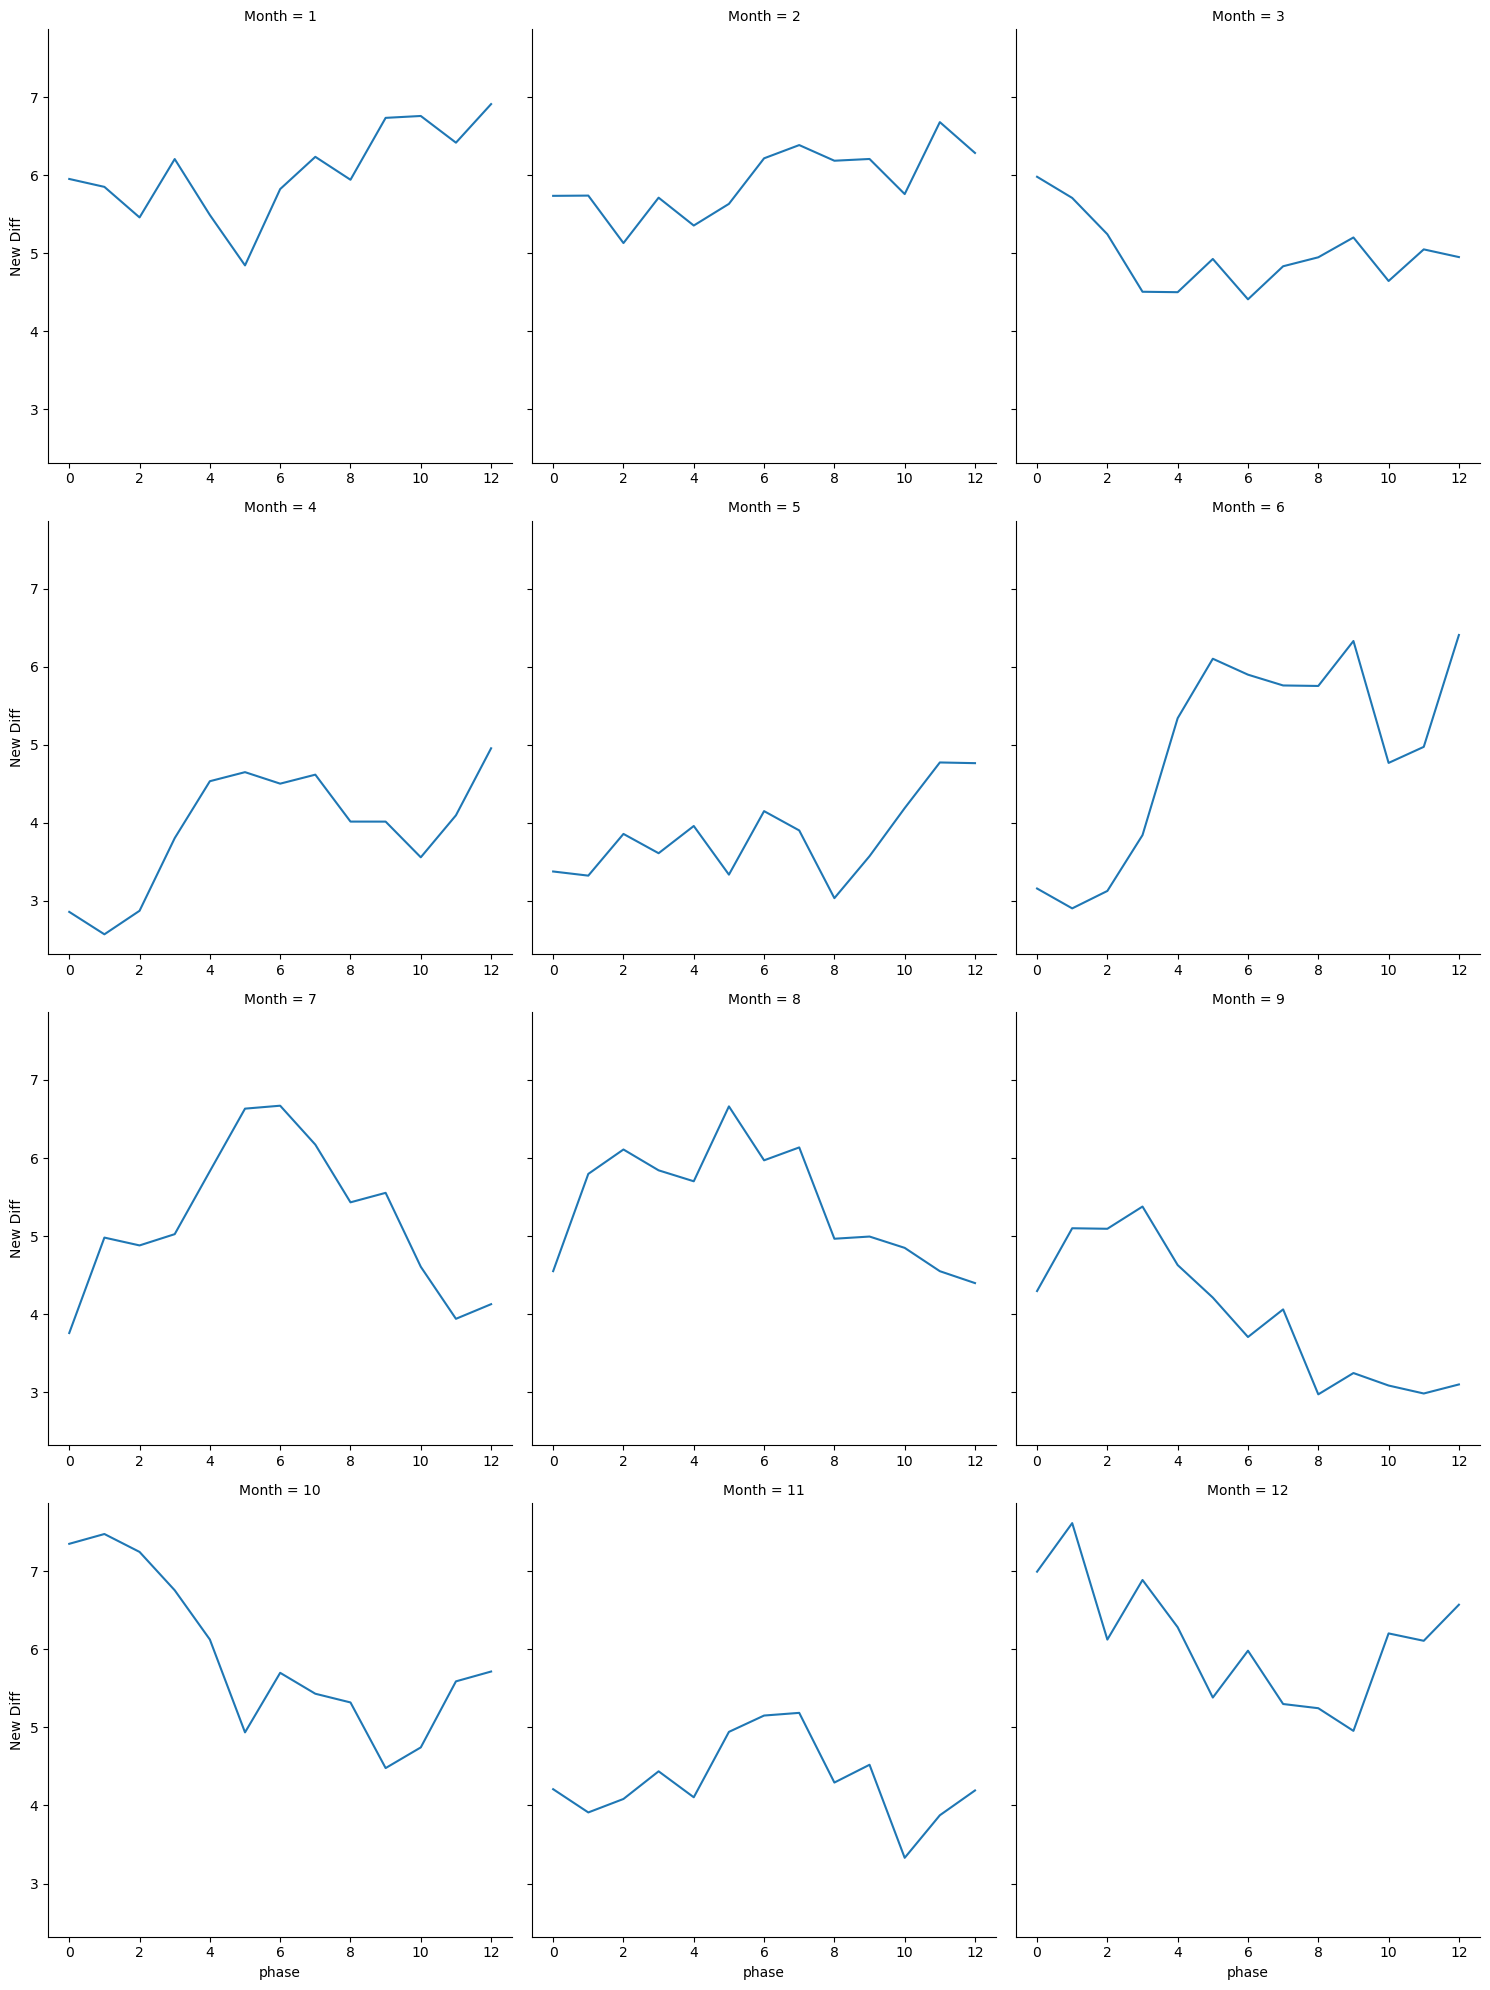

In [52]:
sns.relplot(data=z, x="phase", y="New Diff", kind="line", col="Month",col_wrap=3,facet_kws={'sharex':False})
#sns.relplot(data=z, x="Month", y="New Diff", kind="line", col="phase",col_wrap=3,facet_kws={'sharex':False})



In [53]:
modeldiffs

,Fbin,Obs,CfsDiff,EcmDiff
0,0,61.638161,10.694432,5.093291
1,1,61.929724,10.845791,5.570601
2,2,62.098415,10.940378,5.693369
3,3,62.153443,11.392758,5.671287
4,4,62.199872,11.723504,5.774238
5,5,62.145510,12.064855,5.898530


In [58]:
mldiffs = z.groupby("phase",as_index=False).mean()

In [62]:
mldiffs.drop("Month",axis=1,inplace=True)

In [65]:
modeldiffs.rename(columns={"Fbin":"phase"},inplace=True)

In [66]:
mldiffs

,phase,New Diff
0,0,4.851944
1,1,5.081862
2,2,4.936081
3,3,5.167724
4,4,5.154773
5,5,5.188420
6,6,5.348448
7,7,5.335087
8,8,4.842627
9,9,4.984447


In [67]:
modeldiffs

,phase,Obs,CfsDiff,EcmDiff
0,0,61.638161,10.694432,5.093291
1,1,61.929724,10.845791,5.570601
2,2,62.098415,10.940378,5.693369
3,3,62.153443,11.392758,5.671287
4,4,62.199872,11.723504,5.774238
5,5,62.145510,12.064855,5.898530


In [71]:
all = pd.merge(left=mldiffs,right=modeldiffs,on="phase",how="left")

In [77]:
all.rename(columns={"New Diff":"MLDiff"},inplace=True)

In [ ]:
sns.relplot(data=all, x="phase", y="New Diff", kind="line", col="Month",col_wrap=3,facet_kws={'sharex':False})


<Axes: xlabel='# Month Forecast'>

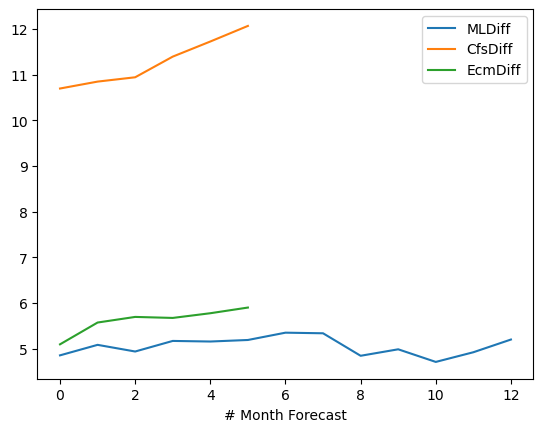

In [80]:
#all.rename(columns={"phase":"# Month Forecast"},inplace=True)

all.plot(x="# Month Forecast",y=["MLDiff","CfsDiff","EcmDiff"])

In [31]:
a=train.groupby(["Month","period","neurons"],as_index=False)[["Obs","New Diff"]].agg(["mean","std"])

In [32]:
a.head()

Month period neurons        Obs           New Diff          
                             mean      std      mean       std
0     1     12     100  18.633333  2.23417  6.376738  4.456666
1     1     12     150  18.633333  2.23417  5.538746  4.489017
2     1     12     200  18.633333  2.23417  6.053786  4.612207
3     1     12     250  18.633333  2.23417  5.552190  5.320949
4     1     24     100  18.633333  2.23417  5.084033  5.674183

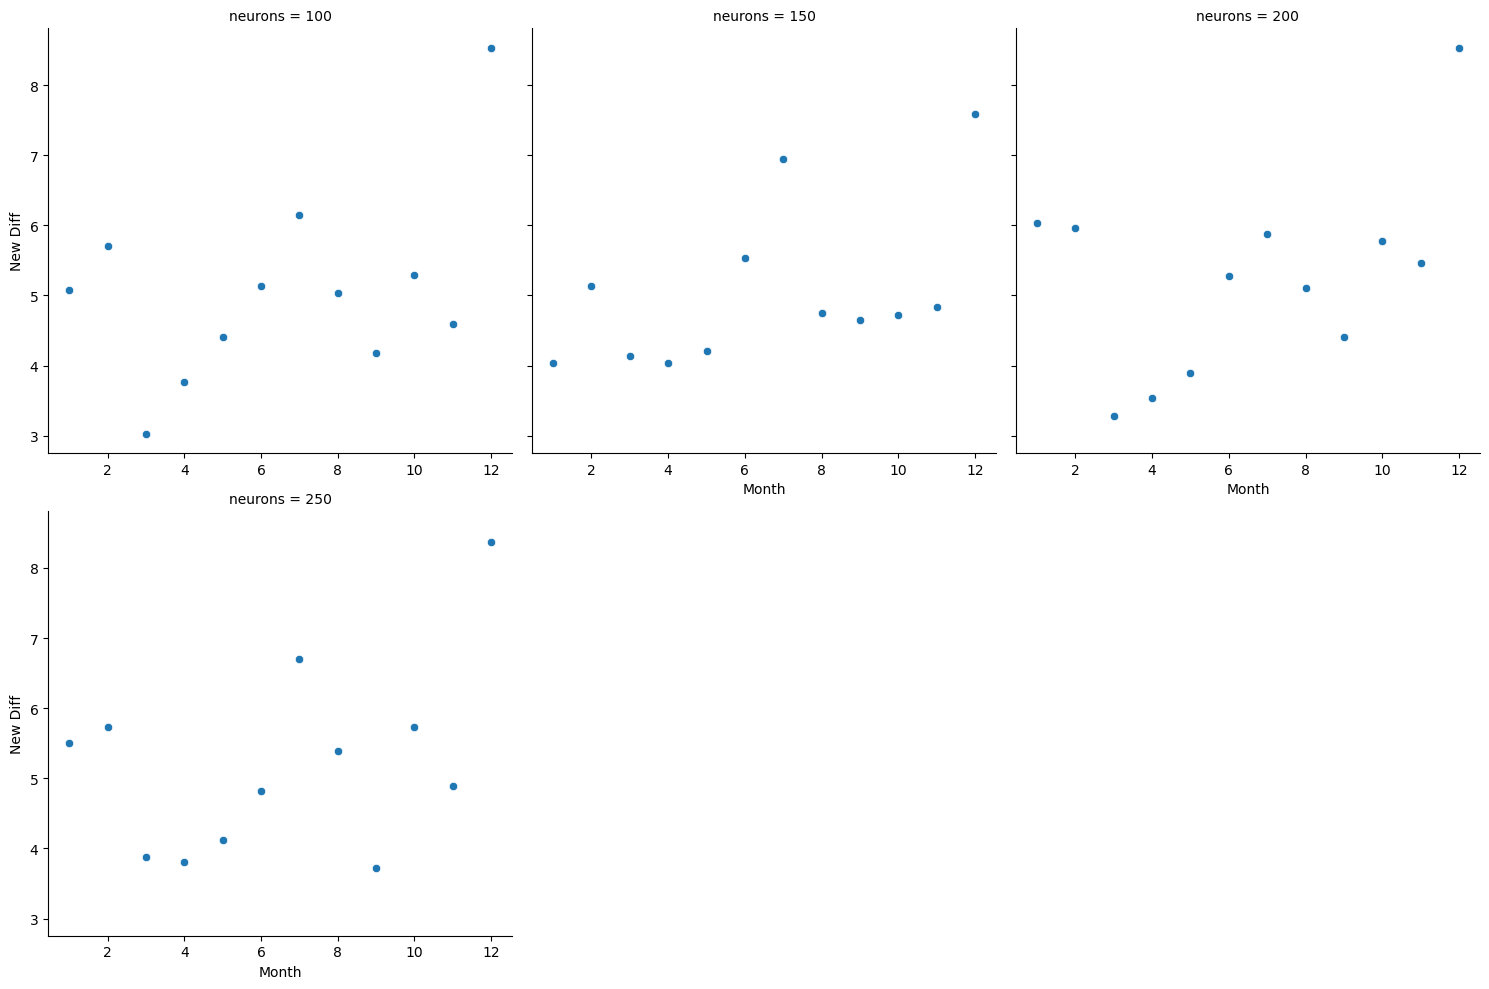

In [40]:
sns.relplot(data=e.loc[a["period"] == 24], x="Month", y="New Diff",  col="neurons",col_wrap=3,facet_kws={'sharex':False})

In [36]:
e.head(100)

,Month,period,neurons,New Diff
0,1,12,100,6.376738
1,1,12,150,5.538746
2,1,12,200,6.053786
3,1,12,250,5.552190
4,1,24,100,5.084033
5,1,24,150,4.041082
6,1,24,200,6.029034
7,1,24,250,5.504538
8,2,12,100,6.466336
9,2,12,150,6.901214


In [39]:
a

,Month,period,neurons,New Diff
0,1,12,100,6.376738
1,1,12,150,5.538746
2,1,12,200,6.053786
3,1,12,250,5.552190
4,1,24,100,5.084033
5,1,24,150,4.041082
6,1,24,200,6.029034
7,1,24,250,5.504538
8,2,12,100,6.466336
9,2,12,150,6.901214


In [43]:
e.loc[e["period"] == 12,"New Diff"]/e.loc[e["period"] == 24,"New Diff"]

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
20   NaN
21   NaN
22   NaN
23   NaN
24   NaN
25   NaN
26   NaN
27   NaN
28   NaN
29   NaN
30   NaN
31   NaN
32   NaN
33   NaN
34   NaN
35   NaN
36   NaN
37   NaN
38   NaN
39   NaN
40   NaN
41   NaN
42   NaN
43   NaN
44   NaN
45   NaN
46   NaN
47   NaN
48   NaN
49   NaN
50   NaN
51   NaN
52   NaN
53   NaN
54   NaN
55   NaN
56   NaN
57   NaN
58   NaN
59   NaN
60   NaN
61   NaN
62   NaN
63   NaN
64   NaN
65   NaN
66   NaN
67   NaN
68   NaN
69   NaN
70   NaN
71   NaN
72   NaN
73   NaN
74   NaN
75   NaN
76   NaN
77   NaN
78   NaN
79   NaN
80   NaN
81   NaN
82   NaN
83   NaN
84   NaN
85   NaN
86   NaN
87   NaN
88   NaN
89   NaN
90   NaN
91   NaN
92   NaN
93   NaN
94   NaN
95   NaN
Name: New Diff, dtype: float64

In [49]:
for index,row in e.loc[e["period"] == 12].iterrows():
    mon = row["Month"]
    neu = row["neurons"]
    diff = row["New Diff"]
    tmp = e.loc[(e["period"] == 24) & (e["Month"] == mon) & (e["neurons"] == neu),"New Diff"].values[0]
    print(mon,neu,diff,tmp,tmp/diff)

1.0 100.0 6.376737975267996 5.084033333755817 0.7972780681085064
1.0 150.0 5.538745999875172 4.041081553040729 0.7296022516887043
1.0 200.0 6.053785635038522 6.029034386666041 0.9959114428781184
1.0 250.0 5.552190045438015 5.504537776426513 0.9914173923043835
2.0 100.0 6.466335792170821 5.71269565304857 0.8834517471185569
2.0 150.0 6.901214468246384 5.130651423889021 0.7434418170158291
2.0 200.0 6.3758756540936 5.958665977054026 0.9345643328580746
2.0 250.0 6.238798910364646 5.731062664135613 0.9186163469084537
3.0 100.0 3.1649131079884505 3.030280099174661 0.9574607566716549
3.0 150.0 3.2438857586293444 4.140463136383416 1.276389936164986
3.0 200.0 3.1886360787192607 3.2861205536941163 1.0305724681551025
3.0 250.0 3.2714260836022775 3.8780453467973666 1.1854296101127617
4.0 100.0 2.762064986617529 3.771383688458698 1.3654217792598708
4.0 150.0 3.0429314161572787 4.039152287111899 1.327388539112289
4.0 200.0 2.260501116277833 3.531072938236994 1.5620752906555955
4.0 250.0 2.73875957949

In [50]:
a

,Month,period,neurons,New Diff
0,1,12,100,6.376738
1,1,12,150,5.538746
2,1,12,200,6.053786
3,1,12,250,5.552190
4,1,24,100,5.084033
5,1,24,150,4.041082
6,1,24,200,6.029034
7,1,24,250,5.504538
8,2,12,100,6.466336
9,2,12,150,6.901214


In [51]:
a.groupby(["period","neurons"]).mean()

Month  New Diff
period neurons                 
12     100        6.5  5.731382
       150        6.5  5.805618
       200        6.5  5.619547
       250        6.5  5.623863
24     100        6.5  5.077673
       150        6.5  5.047667
       200        6.5  5.261955
       250        6.5  5.220613

In [143]:
test.head()

,Date,Obs,Year,Month,neuro_how,period,phase,nbatch,epochs,neurons,dtype,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8,Pred 9,Ens Mean,New Diff
0,200901,47.6,2009,1,2,24,0,16,50,100,0,49.611611,52.442860,46.256315,56.833353,49.222202,57.759987,46.550056,46.465105,53.607973,46.656256,50.643790,3.043790
1,200902,52.9,2009,2,2,24,0,16,50,100,0,46.996123,44.333747,43.029353,47.651288,45.357053,52.326365,46.196319,48.400479,49.714254,42.775539,46.642711,6.257289
2,200903,56.6,2009,3,2,24,0,16,50,100,0,52.578919,47.144809,46.734950,45.668225,44.565219,54.017393,49.318869,46.691637,45.590110,43.722367,47.050398,9.549602
3,200904,57.6,2009,4,2,24,0,16,50,100,0,54.281569,52.248518,54.877771,53.872046,54.357860,54.586417,53.022770,52.019166,55.574839,49.899859,53.384361,4.215639
4,200905,65.0,2009,5,2,24,0,16,50,100,0,63.253414,64.432709,61.481822,63.981120,60.516293,63.972952,63.574002,65.902593,60.657576,61.239103,62.862019,2.137981


In [144]:
test.loc[test["epochs"] == 150].groupby(["phase","Month"])["New Diff"].mean()

phase  Month
0      1        5.542243
       2        6.006015
       3        5.270226
       4        2.671896
       5        3.160269
       6        3.785053
       7        4.316543
       8        4.815256
       9        4.350810
       10       7.723685
       11       4.455254
       12       6.436996
1      1        5.669176
       2        5.820550
       3        4.976105
       4        2.451737
       5        3.390426
       6        2.910716
       7        4.236735
       8        4.886383
       9        4.465832
       10       7.343153
       11       4.238270
       12       7.472924
2      1        5.482877
       2        5.470706
       3        5.195457
       4        2.765119
       5        3.759622
       6        3.524658
       7        4.426926
       8        5.279230
       9        4.579722
       10       7.356068
       11       3.945022
       12       6.208548
3      1        6.261510
       2        6.103546
       3        4.359350
       4    

In [145]:
train.loc[train["epochs"] == 150].groupby(["phase","Month"])["New Diff"].mean()


phase  Month
0      1        5.542243
       2        6.006015
       3        5.270226
       4        2.671896
       5        3.160269
       6        3.785053
       7        4.316543
       8        4.815256
       9        4.350810
       10       7.723685
       11       4.455254
       12       6.436996
1      1        5.669176
       2        5.820550
       3        4.976105
       4        2.451737
       5        3.390426
       6        2.910716
       7        4.236735
       8        4.886383
       9        4.465832
       10       7.343153
       11       4.238270
       12       7.472924
2      1        5.482877
       2        5.470706
       3        5.195457
       4        2.765119
       5        3.759622
       6        3.524658
       7        4.426926
       8        5.279230
       9        4.579722
       10       7.356068
       11       3.945022
       12       6.208548
3      1        6.261510
       2        6.103546
       3        4.359350
       4    